In [1]:
import sys
!{sys.executable} -m pip install pandas numpy matplotlib scikit-learn seaborn umap-learn


[notice] A new release of pip is available: 24.0 -> 25.3
[notice] To update, run: pip3 install --upgrade pip


In [2]:
import pandas as pd
pd.set_option('display.max_columns', None)

import numpy as np
import matplotlib.pyplot as plt

# Dataset Cleaning

In [17]:
# Oensingen 2021-23 dataset
df_2 = pd.read_csv("../datasets/Oensingen_2021-23.csv")
df_2.columns

/var/folders/_3/dhm9h5w122sfbk56zms0llk00000gn/T/ipykernel_96817/4265428201.py:2: DtypeWarning: Columns (628) have mixed types. Specify dtype option on import or set low_memory=False.
  df_2 = pd.read_csv("../datasets/Oensingen_2021-23.csv")


Index(['TIMESTAMP_MIDDLE', 'AIR_CP', 'AIR_DENSITY', 'AIR_MV', 'AIR_RHO_CP',
       'AOA_METHOD', 'AXES_ROTATION_METHOD', 'BADM_HEIGHTC',
       'BADM_INSTPAIR_EASTWARD_SEP_GA_CH4',
       'BADM_INSTPAIR_EASTWARD_SEP_GA_CO2',
       ...
       'GPP_U16_f_reddyproc', 'NEE_U50_f_reddyproc', 'Reco_U50_reddyproc',
       'GPP_U50_f_reddyproc', 'NEE_U84_f_reddyproc', 'Reco_U84_reddyproc',
       'GPP_U84_f_reddyproc', 'LE_f_reddyproc', 'H_f_reddyproc',
       'ET_f_reddyproc'],
      dtype='object', length=730)

In [18]:
df_2.head(10)

,TIMESTAMP_MIDDLE,AIR_CP,AIR_DENSITY,AIR_MV,AIR_RHO_CP,AOA_METHOD,AXES_ROTATION_METHOD,BADM_HEIGHTC,BADM_INSTPAIR_EASTWARD_SEP_GA_CH4,BADM_INSTPAIR_EASTWARD_SEP_GA_CO2,BADM_INSTPAIR_EASTWARD_SEP_GA_H2O,BADM_INSTPAIR_EASTWARD_SEP_GA_N2O,BADM_INSTPAIR_HEIGHT_SEP_GA_CH4,BADM_INSTPAIR_HEIGHT_SEP_GA_CO2,BADM_INSTPAIR_HEIGHT_SEP_GA_H2O,BADM_INSTPAIR_HEIGHT_SEP_GA_N2O,BADM_INSTPAIR_NORTHWARD_SEP_GA_CH4,BADM_INSTPAIR_NORTHWARD_SEP_GA_CO2,BADM_INSTPAIR_NORTHWARD_SEP_GA_H2O,BADM_INSTPAIR_NORTHWARD_SEP_GA_N2O,BADM_INST_AVERAGING_INT,BADM_INST_GA_CP_TUBE_FLOW_RATE_GA_CH4,BADM_INST_GA_CP_TUBE_FLOW_RATE_GA_CO2,BADM_INST_GA_CP_TUBE_FLOW_RATE_GA_H2O,BADM_INST_GA_CP_TUBE_FLOW_RATE_GA_N2O,BADM_INST_GA_CP_TUBE_IN_DIAM_GA_CH4,BADM_INST_GA_CP_TUBE_IN_DIAM_GA_CO2,BADM_INST_GA_CP_TUBE_IN_DIAM_GA_H2O,BADM_INST_GA_CP_TUBE_IN_DIAM_GA_N2O,BADM_INST_GA_CP_TUBE_LENGTH_GA_CH4,BADM_INST_GA_CP_TUBE_LENGTH_GA_CO2,BADM_INST_GA_CP_TUBE_LENGTH_GA_H2O,BADM_INST_GA_CP_TUBE_LENGTH_GA_N2O,BADM_INST_HEIGHT_SA,BADM_INST_SAMPLING_INT,BADM_LOCATION_ELEV,BADM_LOCATION_LAT,BADM_LOCATION_LONG,BADM_SA_OFFSET_NORTH,BOWEN,BURBA_METHOD,CH4,CH4_ABSLIM_NREX,CH4_DIAG_NREX,CH4_KID,CH4_LGD,CH4_MEAS_KUR,CH4_MEAS_MEDIAN,CH4_MEAS_N2O_MEAS_COV,CH4_MEAS_P25,CH4_MEAS_P75,CH4_MEAS_SIGMA,CH4_MEAS_SKW,CH4_MEAS_TYPE,CH4_MIXING_RATIO,CH4_MOLAR_DENSITY,CH4_NR,CH4_NUM_SPIKES,CH4_SPIKE_NREX,CH4_TLAG_ACTUAL,CH4_TLAG_MAX,CH4_TLAG_MIN,CH4_TLAG_NOMINAL,CH4_TLAG_USED,CH4_VM97_TEST,CH4_ZCD,CO2,CO2_ABSLIM_NREX,CO2_DIAG_NREX,CO2_KID,CO2_LGD,CO2_MEAS_H2O_MEAS_COV,CO2_MEAS_KUR,CO2_MEAS_MEDIAN,CO2_MEAS_P25,CO2_MEAS_P75,CO2_MEAS_SIGMA,CO2_MEAS_SKW,CO2_MEAS_TYPE,CO2_MIXING_RATIO,CO2_MOLAR_DENSITY,CO2_NR,CO2_NUM_SPIKES,CO2_SPIKE_NREX,CO2_TLAG_ACTUAL,CO2_TLAG_MAX,CO2_TLAG_MIN,CO2_TLAG_NOMINAL,CO2_TLAG_USED,CO2_VM97_TEST,CO2_ZCD,CUSTOM_AIR_P_MEAN,CUSTOM_CH4_MEAN,CUSTOM_CO2_MEAN,CUSTOM_COOLER_V_MEAN,CUSTOM_DATA_SIZE_IRGA72_MEAN,CUSTOM_DATA_SIZE_LGR_MEAN,CUSTOM_FILTER_NR,CUSTOM_FILTER_NREX,CUSTOM_FIT_FLAG_MEAN,CUSTOM_FLOWRATE_MEAN,CUSTOM_GA_DIAG_CODE_IRGA72_MEAN,CUSTOM_H2O_MEAN,CUSTOM_MIRROR_RINGDOWNTIME_MEAN,CUSTOM_N2O_MEAN,CUSTOM_SIGNAL_STRENGTH_IRGA72_MEAN,CUSTOM_STATUS_CODE_IRGA72_MEAN,CUSTOM_STATUS_CODE_LGR_MEAN,CUSTOM_T_UNKNOWN_MEAN,DENTRENDING_TIME_CONSTANT,DETRENDING_METHOD,DISPLACEMENT_HEIGHT,DOY_END,DOY_START,DRYAIR_DENSITY,DRYAIR_MV,DRYAIR_PARTIAL_PRESSURE,ET,ET_CORRDIFF,ET_RANDUNC_HF,ET_SCF,ET_SSITC_TEST,ET_STAGE1,ET_STAGE2,ET_UNCORR,EXPECT_NR,FC,FCH4,FCH4_CORRDIFF,FCH4_NR,FCH4_NSR,FCH4_RANDUNC_HF,FCH4_SCF,FCH4_SS,FCH4_SSITC_TEST,FCH4_SS_TEST,FCH4_STAGE1,FCH4_STAGE2,FCH4_UNCORR,FCH4_VADV,FC_CORRDIFF,FC_NR,FC_NSR,FC_RANDUNC_HF,FC_SCF,FC_SS,FC_SSITC_TEST,FC_SS_TEST,FC_STAGE1,FC_STAGE2,FC_UNCORR,FC_VADV,FETCH_10,FETCH_30,FETCH_50,FETCH_70,FETCH_80,FETCH_90,FETCH_MAX,FETCH_OFFSET,FH2O,FH2O_CORRDIFF,FH2O_NSR,FH2O_RANDUNC_HF,FH2O_SCF,FH2O_SS,FH2O_SSITC_TEST,FH2O_SS_TEST,FH2O_STAGE1,FH2O_STAGE2,FH2O_UNCORR,FH2O_VADV,FILE_NR,FILE_TIME_DURATION,FLAG_PPFD_IN_ISFILLED,FLAG_SWC_0.05_gfXG_ISFILLED,FLAG_SWC_0.15_gfXG_ISFILLED,FLAG_SWC_0.3_gfXG_ISFILLED,FLAG_SWC_0.5_gfXG_ISFILLED,FLAG_SW_IN_ISFILLED,FLAG_TA_ISFILLED,FLAG_TS_0.05_gfXG_ISFILLED,FLAG_TS_0.15_gfXG_ISFILLED,FLAG_TS_0.3_gfXG_ISFILLED,FLAG_TS_0.5_gfXG_ISFILLED,FLAG_VPD_ISFILLED,FN2O,FN2O_CORRDIFF,FN2O_NR,FN2O_NSR,FN2O_RANDUNC_HF,FN2O_SCF,FN2O_SS,FN2O_SSITC_TEST,FN2O_SS_TEST,FN2O_STAGE1,FN2O_STAGE2,FN2O_UNCORR,FN2O_VADV,FOOTPRINT_MODEL,H,H2O,H2O_ABSLIM_NREX,H2O_DIAG_NREX,H2O_KID,H2O_LGD,H2O_MEAS_CH4_MEAS_COV,H2O_MEAS_KUR,H2O_MEAS_MEDIAN,H2O_MEAS_N2O_MEAS_COV,H2O_MEAS_P25,H2O_MEAS_P75,H2O_MEAS_SIGMA,H2O_MEAS_SKW,H2O_MEAS_TYPE,H2O_MIXING_RATIO,H2O_MOLAR_DENSITY,H2O_NR,H2O_NUM_SPIKES,H2O_SPIKE_NREX,H2O_TLAG_ACTUAL,H2O_TLAG_MAX,H2O_TLAG_MIN,H2O_TLAG_NOMINAL,H2O_TLAG_USED,H2O_VM97_TEST,H2O_ZCD,HPATH_GA_CH4,HPATH_GA_CO2,HPATH_GA_H2O,HPATH_GA_N2O,HPATH_SA,H_CORRDIFF,H_NR,H_NSR,H_RANDUNC_HF,H_SCF,H_SS,H_SSITC_TEST,H_SS_TEST,H_STAGE1,H_STAGE2,H_UNCORR,INST_LI7200_AGC_OR_RSSI,INST_LI7500_AGC_OR_RSSI,LE,LE_CORRDIFF,LE_NR,LE_RANDUNC_HF,LE_SCF,LE_SSITC_TEST,LE_STAGE1,LE

In [42]:
cols = [
    # Target
    "FN2O_L3.1_L3.3_CUT_50_QCF0",

    # Timestamp
    "TIMESTAMP_MIDDLE",
    
    # Predictors
    "NEE_L3.1_L3.3_CUT_50_QCF_gfRF",
    "GPP_U50_f_reddyproc",
    "Reco_U50_reddyproc",
    "SW_IN",
    "TA",
    "PREC",
    "VPD",                     # Vapor pressure deficit
    "SWC_0.05",
    "SWC_0.15",
    "SWC_0.3",
    "TS_0.05",
    "TS_0.15",
    "TS_0.3",
    "MGMT_HARVEST",
    "MGMT_FERT_ORG",
    "MGMT_FERT_MIN",
    "MGMT_SOILCULTIVATION"
]

oensingen_21_23 = df_2[cols]

rename_map = {
    "FN2O_L3.1_L3.3_CUT_50_QCF0": "N2O_Flux",
    "TIMESTAMP_MIDDLE": "Timestamp",
    "NEE_L3.1_L3.3_CUT_50_QCF_gfRF": "NEE",    # Net CO₂ exchange between field and atmosphere (positive = CO₂ released, negative = CO₂ uptake)
    "GPP_U50_f_reddyproc": "GPP",            # Total CO₂ fixed by photosynthesis (proxy for plant growth)
    "Reco_U50_reddyproc": "RECO",            # CO₂ emitted via respiration of plants and soil organisms
    "SW_IN": "SolarRadiation",
    "TA": "AirTemp",
    "PREC": "Precipitation",
    "SWC_0.05": "SoilWater_5cm",
    "SWC_0.15": "SoilWater_15cm",
    "SWC_0.3": "SoilWater_30cm",
    "TS_0.05": "SoilTemp_5cm",
    "TS_0.15": "SoilTemp_15cm",
    "TS_0.3": "SoilTemp_30cm",
    "MGMT_HARVEST": "Mowing",
    "MGMT_FERT_ORG": "FertilizerOrganic",
    "MGMT_FERT_MIN": "FertilizerMineral",
    "MGMT_SOILCULTIVATION": "SoilCultivation",
}

oensingen_2 = oensingen_21_23.rename(columns=rename_map)

oensingen_2["Timestamp"] = pd.to_datetime(oensingen_2["Timestamp"], dayfirst=True)
oensingen_2 = oensingen_2.sort_values("Timestamp")

# Remove duplicate timestamps if any
oensingen_2  = oensingen_2.drop_duplicates(subset=["Timestamp"], keep="first")

oensingen_2["year"] = oensingen_2["Timestamp"].dt.year
oensingen_2["month"] = oensingen_2["Timestamp"].dt.month
oensingen_2["hour"] = oensingen_2["Timestamp"].dt.hour
oensingen_2["day"] = oensingen_2["Timestamp"].dt.day

# --- Prepare for lag feature computation ---
# --- Prepare for lag feature computation ---
oensingen_2 = oensingen_2.set_index("Timestamp").sort_index()

# Daily key
oensingen_2["Date"] = oensingen_2.index.floor("D")

# Daily aggregation
oensingen_daily = (
    oensingen_2
    .groupby("Date", dropna=False)
    .agg({
        "N2O_Flux": "mean",
        "NEE": "mean",
        "GPP": "mean",
        "RECO": "mean",
        "SolarRadiation": "mean",
        "AirTemp": "mean",
        "VPD": "mean",
        "SoilWater_5cm": "mean",
        "SoilWater_15cm": "mean",
        "SoilWater_30cm": "mean",
        "SoilTemp_5cm": "mean",
        "SoilTemp_15cm": "mean",
        "SoilTemp_30cm": "mean",
        "Precipitation": "sum",

        # Management flags
        "Mowing": "max",
        "FertilizerOrganic": "max",
        "FertilizerMineral": "max",
        "SoilCultivation": "max",
    })
    .reset_index()
    .sort_values("Date")
)
# Daily index
oensingen_daily = oensingen_daily.set_index("Date").asfreq("D")
oensingen_daily.index.name = "Date"

meteo_daily = [
    "NEE","GPP","RECO",
    "SolarRadiation","AirTemp","VPD",
    "SoilWater_5cm","SoilWater_15cm","SoilWater_30cm",
    "SoilTemp_5cm","SoilTemp_15cm","SoilTemp_30cm",
    "Precipitation"
]

lag_days     = [1, 3, 5, 7]
roll_windows = [3, 5, 7]

lagcols = []

# --- Lags ---
for var in meteo_daily:
    for lag in lag_days:
        lagcols.append(
            oensingen_daily[var].shift(lag).rename(f"{var}_lag{lag}d_daily")
        )

# --- Rolling windows (shifted) ---
shifted = oensingen_daily[meteo_daily].shift(1)

for var in meteo_daily:
    for w in roll_windows:
        lagcols.append(
            shifted[var].rolling(w, min_periods=1).mean().rename(f"{var}_roll{w}d_mean")
        )
        lagcols.append(
            shifted[var].rolling(w, min_periods=1).sum().rename(f"{var}_roll{w}d_sum")
        )

# Combine into features table
oensingen_daily_features = pd.concat(lagcols, axis=1).reset_index()

oensingen_2 = oensingen_2.reset_index()  # restore Timestamp column
oensingen_2["Date"] = oensingen_2["Timestamp"].dt.floor("D")

oensingen_2 = oensingen_2.merge(
    oensingen_daily_features,
    how="left",
    on="Date"
)

oensingen_2 = oensingen_2.set_index("Timestamp").sort_index()

# FIX: Remove Feb 27 FertilizerMineral flag (will be shifted to Feb 25)
feb27_mask = oensingen_2.index.date == pd.Timestamp('2023-02-27').date()
oensingen_2.loc[feb27_mask, "FertilizerMineral"] = 0

# FIX: Set FertilizerMineral flag for Feb 25 instead
feb25_mask = oensingen_2.index.date == pd.Timestamp('2023-02-25').date()
oensingen_2.loc[feb25_mask, "FertilizerMineral"] = 1

# NOW compute days since events on the daily data
def days_since_event_daily(series, max_days=30):
    """Days since last management event, capped at max_days."""
    days = np.full(len(series), max_days, dtype=float)
    last_event_idx = None
    
    for i in range(len(series)):
        if series.iloc[i] == 1:
            last_event_idx = i
            days[i] = 0
        elif last_event_idx is not None:
            days[i] = min(i - last_event_idx, max_days)
        else:
            days[i] = max_days
    
    return days

for event in ["Mowing", "FertilizerOrganic", "FertilizerMineral", "SoilCultivation"]:
    oensingen_2[f"DaysSince_{event}"] = days_since_event_daily(oensingen_2[event])

# --- transformation ---
oensingen_2 = oensingen_2[oensingen_2["N2O_Flux"].notna()]

oensingen_2["N2O_Flux_ln"] = np.where(
    oensingen_2["N2O_Flux"] > 0,
    np.log1p(oensingen_2["N2O_Flux"]),
    0  # replace neg with 0
)

/var/folders/_3/dhm9h5w122sfbk56zms0llk00000gn/T/ipykernel_96817/186249321.py:53: UserWarning: Parsing dates in %Y-%m-%d %H:%M:%S format when dayfirst=True was specified. Pass `dayfirst=False` or specify a format to silence this warning.
  oensingen_2["Timestamp"] = pd.to_datetime(oensingen_2["Timestamp"], dayfirst=True)
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: invalid value encountered in log1p
  result = getattr(ufunc, method)(*inputs, **kwargs)


In [43]:
oensingen_2.tail(10)

,N2O_Flux,NEE,GPP,RECO,SolarRadiation,AirTemp,Precipitation,VPD,SoilWater_5cm,SoilWater_15cm,SoilWater_30cm,SoilTemp_5cm,SoilTemp_15cm,SoilTemp_30cm,Mowing,FertilizerOrganic,FertilizerMineral,SoilCultivation,year,month,hour,day,Date,NEE_lag1d_daily,NEE_lag3d_daily,NEE_lag5d_daily,NEE_lag7d_daily,GPP_lag1d_daily,GPP_lag3d_daily,GPP_lag5d_daily,GPP_lag7d_daily,RECO_lag1d_daily,RECO_lag3d_daily,RECO_lag5d_daily,RECO_lag7d_daily,SolarRadiation_lag1d_daily,SolarRadiation_lag3d_daily,SolarRadiation_lag5d_daily,SolarRadiation_lag7d_daily,AirTemp_lag1d_daily,AirTemp_lag3d_daily,AirTemp_lag5d_daily,AirTemp_lag7d_daily,VPD_lag1d_daily,VPD_lag3d_daily,VPD_lag5d_daily,VPD_lag7d_daily,SoilWater_5cm_lag1d_daily,SoilWater_5cm_lag3d_daily,SoilWater_5cm_lag5d_daily,SoilWater_5cm_lag7d_daily,SoilWater_15cm_lag1d_daily,SoilWater_15cm_lag3d_daily,SoilWater_15cm_lag5d_daily,SoilWater_15cm_lag7d_daily,SoilWater_30cm_lag1d_daily,SoilWater_30cm_lag3d_daily,SoilWater_30cm_lag5d_daily,SoilWater_30cm_lag7d_daily,SoilTemp_5cm_lag1d_daily,SoilTemp_5cm_lag3d_daily,SoilTemp_5cm_lag5d_daily,SoilTemp_5cm_lag7d_daily,SoilTemp_15cm_lag1d_daily,SoilTemp_15cm_lag3d_daily,SoilTemp_15cm_lag5d_daily,SoilTemp_15cm_lag7d_daily,SoilTemp_30cm_lag1d_daily,SoilTemp_30cm_lag3d_daily,SoilTemp_30cm_lag5d_daily,SoilTemp_30cm_lag7d_daily,Precipitation_lag1d_daily,Precipitation_lag3d_daily,Precipitation_lag5d_daily,Precipitation_lag7d_daily,NEE_roll3d_mean,NEE_roll3d_sum,NEE_roll5d_mean,NEE_roll5d_sum,NEE_roll7d_mean,NEE_roll7d_sum,GPP_roll3d_mean,GPP_roll3d_sum,GPP_roll5d_mean,GPP_roll5d_sum,GPP_roll7d_mean,GPP_roll7d_sum,RECO_roll3d_mean,RECO_roll3d_sum,RECO_roll5d_mean,RECO_roll5d_sum,RECO_roll7d_mean,RECO_roll7d_sum,SolarRadiation_roll3d_mean,SolarRadiation_roll3d_sum,SolarRadiation_roll5d_mean,SolarRadiation_roll5d_sum,SolarRadiation_roll7d_mean,SolarRadiation_roll7d_sum,AirTemp_roll3d_mean,AirTemp_roll3d_sum,AirTemp_roll5d_mean,AirTemp_roll5d_sum,AirTemp_roll7d_mean,AirTemp_roll7d_sum,VPD_roll3d_mean,VPD_roll3d_sum,VPD_roll5d_mean,VPD_roll5d_sum,VPD_roll7d_mean,VPD_roll7d_sum,SoilWater_5cm_roll3d_mean,SoilWater_5cm_roll3d_sum,SoilWater_5cm_roll5d_mean,SoilWater_5cm_roll5d_sum,SoilWater_5cm_roll7d_mean,SoilWater_5cm_roll7d_sum,SoilWater_15cm_roll3d_mean,SoilWater_15cm_roll3d_sum,SoilWater_15cm_roll5d_mean,SoilWater_15cm_roll5d_sum,SoilWater_15cm_roll7d_mean,SoilWater_15cm_roll7d_sum,SoilWater_30cm_roll3d_mean,SoilWater_30cm_roll3d_sum,SoilWater_30cm_roll5d_mean,SoilWater_30cm_roll5d_sum,SoilWater_30cm_roll7d_mean,SoilWater_30cm_roll7d_sum,SoilTemp_5cm_roll3d_mean,SoilTemp_5cm_roll3d_sum,SoilTemp_5cm_roll5d_mean,SoilTemp_5cm_roll5d_sum,SoilTemp_5cm_roll7d_mean,SoilTemp_5cm_roll7d_sum,SoilTemp_15cm_roll3d_mean,SoilTemp_15cm_roll3d_sum,SoilTemp_15cm_roll5d_mean,SoilTemp_15cm_roll5d_sum,SoilTemp_15cm_roll7d_mean,SoilTemp_15cm_roll7d_sum,SoilTemp_30cm_roll3d_mean,SoilTemp_30cm_roll3d_sum,SoilTemp_30cm_roll5d_mean,SoilTemp_30cm_roll5d_sum,SoilTemp_30cm_roll7d_mean,SoilTemp_30cm_roll7d_sum,Precipitation_roll3d_mean,Precipitation_roll3d_sum,Precipitation_roll5d_mean,Precipitation_roll5d_sum,Precipitation_roll7d_mean,Precipitation_roll7d_sum,DaysSince_Mowing,DaysSince_FertilizerOrganic,DaysSince_FertilizerMineral,DaysSince_SoilCultivation,N2O_Flux_ln
Timestamp,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
2023-10-04 17:45:00,1.349012,4.594416,0.852729,4.769436,16.301395,15.959234,0.0,0.692267,18.889286,27.477550,25.639968,15.687222,16.100000,15.844444,0.0,0.0,0.0,0.0,2023,10,17,4,2023-10-04,5.024502,5.398088,6.913138,4.968304,1.081539,0.639169,0.244654,2.611117,5.574894,5.486284,6.743219,6.031155,145.595009,190.605189,183.330853,197.010692,17.527694,14.584311,17.401941,13.293228,0.561947,0.375906,0.585335,0.365434,20.130189,21.462919,23.693651,27.132204,27.819855,28.301269,28.758614,29.231970,25.864910,26.135717,26.352519,26.520217,15.828623,15.560579,15.650914,14.688727,

# Further Analysis and Checks

In [44]:
# Ensure timestamp is datetime and sorted (already done by setting it as index)
# aeschi is already sorted by index since we used set_index() and sort_index()

# Compute time difference between consecutive timestamps using the index
oensingen_2["time_diff"] = oensingen_2.index.to_series().diff()

# Look at large gaps
print(oensingen_2["time_diff"].describe())
oensingen_2[oensingen_2["time_diff"] > pd.Timedelta("3 days")].head(50)

count                         6641
mean     0 days 01:26:57.316669176
std      0 days 05:04:08.891237911
min                0 days 00:30:00
25%                0 days 00:30:00
50%                0 days 00:30:00
75%                0 days 01:00:00
max                9 days 14:00:00
Name: time_diff, dtype: object


,N2O_Flux,NEE,GPP,RECO,SolarRadiation,AirTemp,Precipitation,VPD,SoilWater_5cm,SoilWater_15cm,SoilWater_30cm,SoilTemp_5cm,SoilTemp_15cm,SoilTemp_30cm,Mowing,FertilizerOrganic,FertilizerMineral,SoilCultivation,year,month,hour,day,Date,NEE_lag1d_daily,NEE_lag3d_daily,NEE_lag5d_daily,NEE_lag7d_daily,GPP_lag1d_daily,GPP_lag3d_daily,GPP_lag5d_daily,GPP_lag7d_daily,RECO_lag1d_daily,RECO_lag3d_daily,RECO_lag5d_daily,RECO_lag7d_daily,SolarRadiation_lag1d_daily,SolarRadiation_lag3d_daily,SolarRadiation_lag5d_daily,SolarRadiation_lag7d_daily,AirTemp_lag1d_daily,AirTemp_lag3d_daily,AirTemp_lag5d_daily,AirTemp_lag7d_daily,VPD_lag1d_daily,VPD_lag3d_daily,VPD_lag5d_daily,VPD_lag7d_daily,SoilWater_5cm_lag1d_daily,SoilWater_5cm_lag3d_daily,SoilWater_5cm_lag5d_daily,SoilWater_5cm_lag7d_daily,SoilWater_15cm_lag1d_daily,SoilWater_15cm_lag3d_daily,SoilWater_15cm_lag5d_daily,SoilWater_15cm_lag7d_daily,SoilWater_30cm_lag1d_daily,SoilWater_30cm_lag3d_daily,SoilWater_30cm_lag5d_daily,SoilWater_30cm_lag7d_daily,SoilTemp_5cm_lag1d_daily,SoilTemp_5cm_lag3d_daily,SoilTemp_5cm_lag5d_daily,SoilTemp_5cm_lag7d_daily,SoilTemp_15cm_lag1d_daily,SoilTemp_15cm_lag3d_daily,SoilTemp_15cm_lag5d_daily,SoilTemp_15cm_lag7d_daily,SoilTemp_30cm_lag1d_daily,SoilTemp_30cm_lag3d_daily,SoilTemp_30cm_lag5d_daily,SoilTemp_30cm_lag7d_daily,Precipitation_lag1d_daily,Precipitation_lag3d_daily,Precipitation_lag5d_daily,Precipitation_lag7d_daily,NEE_roll3d_mean,NEE_roll3d_sum,NEE_roll5d_mean,NEE_roll5d_sum,NEE_roll7d_mean,NEE_roll7d_sum,GPP_roll3d_mean,GPP_roll3d_sum,GPP_roll5d_mean,GPP_roll5d_sum,GPP_roll7d_mean,GPP_roll7d_sum,RECO_roll3d_mean,RECO_roll3d_sum,RECO_roll5d_mean,RECO_roll5d_sum,RECO_roll7d_mean,RECO_roll7d_sum,SolarRadiation_roll3d_mean,SolarRadiation_roll3d_sum,SolarRadiation_roll5d_mean,SolarRadiation_roll5d_sum,SolarRadiation_roll7d_mean,SolarRadiation_roll7d_sum,AirTemp_roll3d_mean,AirTemp_roll3d_sum,AirTemp_roll5d_mean,AirTemp_roll5d_sum,AirTemp_roll7d_mean,AirTemp_roll7d_sum,VPD_roll3d_mean,VPD_roll3d_sum,VPD_roll5d_mean,VPD_roll5d_sum,VPD_roll7d_mean,VPD_roll7d_sum,SoilWater_5cm_roll3d_mean,SoilWater_5cm_roll3d_sum,SoilWater_5cm_roll5d_mean,SoilWater_5cm_roll5d_sum,SoilWater_5cm_roll7d_mean,SoilWater_5cm_roll7d_sum,SoilWater_15cm_roll3d_mean,SoilWater_15cm_roll3d_sum,SoilWater_15cm_roll5d_mean,SoilWater_15cm_roll5d_sum,SoilWater_15cm_roll7d_mean,SoilWater_15cm_roll7d_sum,SoilWater_30cm_roll3d_mean,SoilWater_30cm_roll3d_sum,SoilWater_30cm_roll5d_mean,SoilWater_30cm_roll5d_sum,SoilWater_30cm_roll7d_mean,SoilWater_30cm_roll7d_sum,SoilTemp_5cm_roll3d_mean,SoilTemp_5cm_roll3d_sum,SoilTemp_5cm_roll5d_mean,SoilTemp_5cm_roll5d_sum,SoilTemp_5cm_roll7d_mean,SoilTemp_5cm_roll7d_sum,SoilTemp_15cm_roll3d_mean,SoilTemp_15cm_roll3d_sum,SoilTemp_15cm_roll5d_mean,SoilTemp_15cm_roll5d_sum,SoilTemp_15cm_roll7d_mean,SoilTemp_15cm_roll7d_sum,SoilTemp_30cm_roll3d_mean,SoilTemp_30cm_roll3d_sum,SoilTemp_30cm_roll5d_mean,SoilTemp_30cm_roll5d_sum,SoilTemp_30cm_roll7d_mean,SoilTemp_30cm_roll7d_sum,Precipitation_roll3d_mean,Precipitation_roll3d_sum,Precipitation_roll5d_mean,Precipitation_roll5d_sum,Precipitation_roll7d_mean,Precipitation_roll7d_sum,DaysSince_Mowing,DaysSince_FertilizerOrganic,DaysSince_FertilizerMineral,DaysSince_SoilCultivation,N2O_Flux_ln,time_diff
Timestamp,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
2022-09-16 10:15:00,0.960903,5.617257,24.402453,9.281678,35.926946,15.290261,0.0,0.248873,25.110992,19.031319,23.452006,17.827222,18.000000,17.866667,0.0,0.0,0.0,0.0,2022,9,10,16,2022-09-16,3.615367,-1.824683,-1.862783,-0.664446,5.431358,11.813153,10.676709,9.060432,9.373695,10.071041,8.780696,8.195352,50.149196,187.820443,260.167679,236.496548,16.226120,18.184498,16.516474,16.145732,0.052284,0.529727,0.522611,0.468357,25.654322,18.673058,20.055269,22.201301,16.200106,13.339473,14.244761,14.855929,19.857250,16.941041,17.447691,17.920013,18.241412,18.509959,18.

In [45]:
# First, aggregate to daily WITHOUT the DaysSince features
oensingen_2["Date"] = oensingen_2.index.floor("D")

oensingen_2_daily = (
    oensingen_2
    .groupby(["Date"], dropna=False)
    .agg({
        # Continuous fluxes and predictors — daily mean
        "N2O_Flux": "mean",
        "NEE": "mean",
        "GPP": "mean",
        "RECO": "mean",
        "SolarRadiation": "mean",
        "AirTemp": "mean",
        "VPD": "mean",
        "SoilWater_5cm": "mean",
        "SoilWater_15cm": "mean",
        "SoilWater_30cm": "mean",
        "SoilTemp_5cm": "mean",
        "SoilTemp_15cm": "mean",
        "SoilTemp_30cm": "mean",

        # Precipitation — total per day
        "Precipitation": "sum",

        # Management events — any event that day
        "Mowing": "max",
        "FertilizerOrganic": "max",
        "FertilizerMineral": "max",
        "SoilCultivation": "max",

        # Days since management — take min (closest to event)
        "DaysSince_Mowing": "min",
        "DaysSince_FertilizerOrganic": "min",
        "DaysSince_FertilizerMineral": "min",
        "DaysSince_SoilCultivation": "min",
    })
    .reset_index()
    .sort_values(["Date"])
)

# ==========================================================
# --- Compute lag features (calendar-based) ---
# ==========================================================
meteo_daily = [
    "NEE","GPP","RECO",
    "SolarRadiation","AirTemp","VPD",
    "SoilWater_5cm","SoilWater_15cm","SoilWater_30cm",
    "SoilTemp_5cm","SoilTemp_15cm","SoilTemp_30cm",
    "Precipitation"
]

lag_days     = [1, 3, 5, 7]
roll_windows = [3, 5, 7]

# Set Date index
oensingen_2_daily = oensingen_2_daily.set_index("Date").sort_index()
oensingen_2_daily.index.name = "Date"

newcols = []

# --- Simple lags ---
for var in meteo_daily:
    for lag in lag_days:
        newcols.append(
            oensingen_2_daily[var].shift(lag).rename(f"{var}_lag{lag}d")
        )

# --- Rolling means/sums excluding current day ---
shifted = oensingen_2_daily[meteo_daily].shift(1)

for var in meteo_daily:
    for w in roll_windows:
        # mean
        newcols.append(
            shifted[var]
            .rolling(w, min_periods=1)
            .mean()
            .rename(f"{var}_roll{w}d_mean")
        )
        # sum
        newcols.append(
            shifted[var]
            .rolling(w, min_periods=1)
            .sum()
            .rename(f"{var}_roll{w}d_sum")
        )

# Combine into full daily feature table
oensingen_2_daily = pd.concat([oensingen_2_daily] + newcols, axis=1).reset_index()

# ==========================================================
# --- Add temporal helpers and filter ---
# ==========================================================
oensingen_2_daily["Date"] = pd.to_datetime(oensingen_2_daily["Date"])
oensingen_2_daily["year"] = oensingen_2_daily["Date"].dt.year
oensingen_2_daily["month"] = oensingen_2_daily["Date"].dt.month
oensingen_2_daily = oensingen_2_daily[oensingen_2_daily["N2O_Flux"].notna()]

# ==========================================================
# --- Recalculate log-transform (after aggregation) ---
# ==========================================================
oensingen_2_daily["N2O_Flux_ln"] = np.where(
    oensingen_2_daily["N2O_Flux"] > 0,
    np.log1p(oensingen_2_daily["N2O_Flux"]),
    0
)

print(f"Oensingen daily: {oensingen_2_daily.shape}")
oensingen_2_daily.head(10)

Oensingen daily: (374, 156)


,Date,N2O_Flux,NEE,GPP,RECO,SolarRadiation,AirTemp,VPD,SoilWater_5cm,SoilWater_15cm,SoilWater_30cm,SoilTemp_5cm,SoilTemp_15cm,SoilTemp_30cm,Precipitation,Mowing,FertilizerOrganic,FertilizerMineral,SoilCultivation,DaysSince_Mowing,DaysSince_FertilizerOrganic,DaysSince_FertilizerMineral,DaysSince_SoilCultivation,NEE_lag1d,NEE_lag3d,NEE_lag5d,NEE_lag7d,GPP_lag1d,GPP_lag3d,GPP_lag5d,GPP_lag7d,RECO_lag1d,RECO_lag3d,RECO_lag5d,RECO_lag7d,SolarRadiation_lag1d,SolarRadiation_lag3d,SolarRadiation_lag5d,SolarRadiation_lag7d,AirTemp_lag1d,AirTemp_lag3d,AirTemp_lag5d,AirTemp_lag7d,VPD_lag1d,VPD_lag3d,VPD_lag5d,VPD_lag7d,SoilWater_5cm_lag1d,SoilWater_5cm_lag3d,SoilWater_5cm_lag5d,SoilWater_5cm_lag7d,SoilWater_15cm_lag1d,SoilWater_15cm_lag3d,SoilWater_15cm_lag5d,SoilWater_15cm_lag7d,SoilWater_30cm_lag1d,SoilWater_30cm_lag3d,SoilWater_30cm_lag5d,SoilWater_30cm_lag7d,SoilTemp_5cm_lag1d,SoilTemp_5cm_lag3d,SoilTemp_5cm_lag5d,SoilTemp_5cm_lag7d,SoilTemp_15cm_lag1d,SoilTemp_15cm_lag3d,SoilTemp_15cm_lag5d,SoilTemp_15cm_lag7d,SoilTemp_30cm_lag1d,SoilTemp_30cm_lag3d,SoilTemp_30cm_lag5d,SoilTemp_30cm_lag7d,Precipitation_lag1d,Precipitation_lag3d,Precipitation_lag5d,Precipitation_lag7d,NEE_roll3d_mean,NEE_roll3d_sum,NEE_roll5d_mean,NEE_roll5d_sum,NEE_roll7d_mean,NEE_roll7d_sum,GPP_roll3d_mean,GPP_roll3d_sum,GPP_roll5d_mean,GPP_roll5d_sum,GPP_roll7d_mean,GPP_roll7d_sum,RECO_roll3d_mean,RECO_roll3d_sum,RECO_roll5d_mean,RECO_roll5d_sum,RECO_roll7d_mean,RECO_roll7d_sum,SolarRadiation_roll3d_mean,SolarRadiation_roll3d_sum,SolarRadiation_roll5d_mean,SolarRadiation_roll5d_sum,SolarRadiation_roll7d_mean,SolarRadiation_roll7d_sum,AirTemp_roll3d_mean,AirTemp_roll3d_sum,AirTemp_roll5d_mean,AirTemp_roll5d_sum,AirTemp_roll7d_mean,AirTemp_roll7d_sum,VPD_roll3d_mean,VPD_roll3d_sum,VPD_roll5d_mean,VPD_roll5d_sum,VPD_roll7d_mean,VPD_roll7d_sum,SoilWater_5cm_roll3d_mean,SoilWater_5cm_roll3d_sum,SoilWater_5cm_roll5d_mean,SoilWater_5cm_roll5d_sum,SoilWater_5cm_roll7d_mean,SoilWater_5cm_roll7d_sum,SoilWater_15cm_roll3d_mean,SoilWater_15cm_roll3d_sum,SoilWater_15cm_roll5d_mean,SoilWater_15cm_roll5d_sum,SoilWater_15cm_roll7d_mean,SoilWater_15cm_roll7d_sum,SoilWater_30cm_roll3d_mean,SoilWater_30cm_roll3d_sum,SoilWater_30cm_roll5d_mean,SoilWater_30cm_roll5d_sum,SoilWater_30cm_roll7d_mean,SoilWater_30cm_roll7d_sum,SoilTemp_5cm_roll3d_mean,SoilTemp_5cm_roll3d_sum,SoilTemp_5cm_roll5d_mean,SoilTemp_5cm_roll5d_sum,SoilTemp_5cm_roll7d_mean,SoilTemp_5cm_roll7d_sum,SoilTemp_15cm_roll3d_mean,SoilTemp_15cm_roll3d_sum,SoilTemp_15cm_roll5d_mean,SoilTemp_15cm_roll5d_sum,SoilTemp_15cm_roll7d_mean,SoilTemp_15cm_roll7d_sum,SoilTemp_30cm_roll3d_mean,SoilTemp_30cm_roll3d_sum,SoilTemp_30cm_roll5d_mean,SoilTemp_30cm_roll5d_sum,SoilTemp_30cm_roll7d_mean,SoilTemp_30cm_roll7d_sum,Precipitation_roll3d_mean,Precipitation_roll3d_sum,Precipitation_roll5d_mean,Precipitation_roll5d_sum,Precipitation_roll7d_mean,Precipitation_roll7d_sum,year,month,N2O_Flux_ln
0,2022-08-30,0.041912,-4.351038,8.502188,6.947915,390.603387,25.279153,1.375940,16.654028,11.400330,15.092138,23.102152,20.388958,19.403194,0.0,0.0,0.0,0.0,0.0,30.0,30.0,30.0,30.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2022,8,0.041058
1,2022-08-31,0.005960,-5.280456,10.000677,6.309859,356.768688,19.583560,0.554957,16.721685,11.559848,15.025680,21.095166,20.007500,19.443889,1.3,0.0,0.0,0.0,0.0,30.0,30.0,30.0,30.0,-4.351038,NaN,NaN,NaN,8.502188,NaN,NaN,NaN,6.947915,NaN,NaN,NaN,390.603387,NaN,NaN,NaN,25.279153,NaN,NaN,NaN,1.375940,NaN,NaN,NaN,16.654028,NaN,NaN,NaN,11.400330,NaN,NaN

In [46]:
fert_info = pd.read_csv("../datasets/FertilizationInfo_DataScienceLab/Oensingen_2022-23.csv")

# --- Convert fert_info["date"] (yyyymmdd int/string) to datetime ---
# Handles both integer and string formats automatically
oensingen_2_daily["Date"] = pd.to_datetime(oensingen_2_daily["Date"], errors="coerce")
fert_info["date"] = pd.to_datetime(fert_info["date"].astype(str), format="%Y%m%d", errors="coerce")

# FIX: Shift Feb 27 fertilization to Feb 25
fert_info.loc[fert_info["date"] == "2023-02-27", "date"] = pd.Timestamp("2023-02-25")

# --- Merge on Date only (no Parcel for Oensingen) ---
oensingen_2_daily = oensingen_2_daily.merge(
    fert_info,
    how="left",
    left_on="Date",
    right_on="date"
)

# --- Clean up redundant columns if desired ---
oensingen_2_daily.drop(columns=["date"], inplace=True)

# --- Optional: rename fertilizer column for clarity ---
oensingen_2_daily.rename(columns={"N(kg/ha)": "Fertilizer_N_kg_ha"}, inplace=True)

# --- Set Date back as index if desired ---
oensingen_2_daily = oensingen_2_daily.set_index("Date").sort_index()

oensingen_2_daily.head()

,N2O_Flux,NEE,GPP,RECO,SolarRadiation,AirTemp,VPD,SoilWater_5cm,SoilWater_15cm,SoilWater_30cm,SoilTemp_5cm,SoilTemp_15cm,SoilTemp_30cm,Precipitation,Mowing,FertilizerOrganic,FertilizerMineral,SoilCultivation,DaysSince_Mowing,DaysSince_FertilizerOrganic,DaysSince_FertilizerMineral,DaysSince_SoilCultivation,NEE_lag1d,NEE_lag3d,NEE_lag5d,NEE_lag7d,GPP_lag1d,GPP_lag3d,GPP_lag5d,GPP_lag7d,RECO_lag1d,RECO_lag3d,RECO_lag5d,RECO_lag7d,SolarRadiation_lag1d,SolarRadiation_lag3d,SolarRadiation_lag5d,SolarRadiation_lag7d,AirTemp_lag1d,AirTemp_lag3d,AirTemp_lag5d,AirTemp_lag7d,VPD_lag1d,VPD_lag3d,VPD_lag5d,VPD_lag7d,SoilWater_5cm_lag1d,SoilWater_5cm_lag3d,SoilWater_5cm_lag5d,SoilWater_5cm_lag7d,SoilWater_15cm_lag1d,SoilWater_15cm_lag3d,SoilWater_15cm_lag5d,SoilWater_15cm_lag7d,SoilWater_30cm_lag1d,SoilWater_30cm_lag3d,SoilWater_30cm_lag5d,SoilWater_30cm_lag7d,SoilTemp_5cm_lag1d,SoilTemp_5cm_lag3d,SoilTemp_5cm_lag5d,SoilTemp_5cm_lag7d,SoilTemp_15cm_lag1d,SoilTemp_15cm_lag3d,SoilTemp_15cm_lag5d,SoilTemp_15cm_lag7d,SoilTemp_30cm_lag1d,SoilTemp_30cm_lag3d,SoilTemp_30cm_lag5d,SoilTemp_30cm_lag7d,Precipitation_lag1d,Precipitation_lag3d,Precipitation_lag5d,Precipitation_lag7d,NEE_roll3d_mean,NEE_roll3d_sum,NEE_roll5d_mean,NEE_roll5d_sum,NEE_roll7d_mean,NEE_roll7d_sum,GPP_roll3d_mean,GPP_roll3d_sum,GPP_roll5d_mean,GPP_roll5d_sum,GPP_roll7d_mean,GPP_roll7d_sum,RECO_roll3d_mean,RECO_roll3d_sum,RECO_roll5d_mean,RECO_roll5d_sum,RECO_roll7d_mean,RECO_roll7d_sum,SolarRadiation_roll3d_mean,SolarRadiation_roll3d_sum,SolarRadiation_roll5d_mean,SolarRadiation_roll5d_sum,SolarRadiation_roll7d_mean,SolarRadiation_roll7d_sum,AirTemp_roll3d_mean,AirTemp_roll3d_sum,AirTemp_roll5d_mean,AirTemp_roll5d_sum,AirTemp_roll7d_mean,AirTemp_roll7d_sum,VPD_roll3d_mean,VPD_roll3d_sum,VPD_roll5d_mean,VPD_roll5d_sum,VPD_roll7d_mean,VPD_roll7d_sum,SoilWater_5cm_roll3d_mean,SoilWater_5cm_roll3d_sum,SoilWater_5cm_roll5d_mean,SoilWater_5cm_roll5d_sum,SoilWater_5cm_roll7d_mean,SoilWater_5cm_roll7d_sum,SoilWater_15cm_roll3d_mean,SoilWater_15cm_roll3d_sum,SoilWater_15cm_roll5d_mean,SoilWater_15cm_roll5d_sum,SoilWater_15cm_roll7d_mean,SoilWater_15cm_roll7d_sum,SoilWater_30cm_roll3d_mean,SoilWater_30cm_roll3d_sum,SoilWater_30cm_roll5d_mean,SoilWater_30cm_roll5d_sum,SoilWater_30cm_roll7d_mean,SoilWater_30cm_roll7d_sum,SoilTemp_5cm_roll3d_mean,SoilTemp_5cm_roll3d_sum,SoilTemp_5cm_roll5d_mean,SoilTemp_5cm_roll5d_sum,SoilTemp_5cm_roll7d_mean,SoilTemp_5cm_roll7d_sum,SoilTemp_15cm_roll3d_mean,SoilTemp_15cm_roll3d_sum,SoilTemp_15cm_roll5d_mean,SoilTemp_15cm_roll5d_sum,SoilTemp_15cm_roll7d_mean,SoilTemp_15cm_roll7d_sum,SoilTemp_30cm_roll3d_mean,SoilTemp_30cm_roll3d_sum,SoilTemp_30cm_roll5d_mean,SoilTemp_30cm_roll5d_sum,SoilTemp_30cm_roll7d_mean,SoilTemp_30cm_roll7d_sum,Precipitation_roll3d_mean,Precipitation_roll3d_sum,Precipitation_roll5d_mean,Precipitation_roll5d_sum,Precipitation_roll7d_mean,Precipitation_roll7d_sum,year,month,N2O_Flux_ln,Fertilizer_N_kg_ha
Date,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
2022-08-30,0.041912,-4.351038,8.502188,6.947915,390.603387,25.279153,1.375940,16.654028,11.400330,15.092138,23.102152,20.388958,19.403194,0.0,0.0,0.0,0.0,0.0,30.0,30.0,30.0,30.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2022,8,0.041058,NaN
2022-08-31,0.005960,-5.280456,10.000677,6.309859,356.768688,19.583560,0.554957,16.721685,11.559848,15.025680,21.095166,20.007500,19.443889,1.3,0.0,0.0,0.0,0.0,30.0,30.0,30.0

In [47]:
# ==========================================================
# --- Exponential-decay fertilizer stock (Oensingen, no parcels)
# ==========================================================

def add_exponential_decay_single(df, dose_col="Fertilizer_N_kg_ha",
                                 half_lives=(3, 7, 14)):
    """
    Calendar-aware exponential decay for datasets with missing days.
    """
    df = df.sort_index().copy()

    # Fill NaN dose with zero
    dose = df[dose_col].fillna(0).to_numpy(float)

    # Compute day differences between rows
    dates = df.index.to_series()
    delta_days = dates.diff().dt.total_seconds().div(86400).fillna(0).to_numpy()

    for hl in half_lives:
        stock = np.zeros_like(dose)
        acc = 0.0

        for i, x in enumerate(dose):
            if i == 0:
                acc = x
            else:
                # Calendar-aware decay
                decay = 0.5 ** (delta_days[i] / hl)
                acc = x + decay * acc

            stock[i] = acc

        df[f"{dose_col}_expHL{hl}d"] = stock

    return df


# Only run if fertilizer column is present
if "Fertilizer_N_kg_ha" in oensingen_2_daily.columns:
    oensingen_2_daily = add_exponential_decay_single(oensingen_2_daily)
else:
    print("No Fertilizer_N_kg_ha column — skipping exponential decay.")


In [48]:
oensingen_2.to_csv("../datasets/Oensingen_2021-23_clean_newlag.csv")
oensingen_2_daily.to_csv("../datasets/Oensingen_Daily_2021-23_clean_newlag.csv")

In [49]:
oensingen_2_daily[oensingen_2_daily["Fertilizer_N_kg_ha"].notna()]

,N2O_Flux,NEE,GPP,RECO,SolarRadiation,AirTemp,VPD,SoilWater_5cm,SoilWater_15cm,SoilWater_30cm,SoilTemp_5cm,SoilTemp_15cm,SoilTemp_30cm,Precipitation,Mowing,FertilizerOrganic,FertilizerMineral,SoilCultivation,DaysSince_Mowing,DaysSince_FertilizerOrganic,DaysSince_FertilizerMineral,DaysSince_SoilCultivation,NEE_lag1d,NEE_lag3d,NEE_lag5d,NEE_lag7d,GPP_lag1d,GPP_lag3d,GPP_lag5d,GPP_lag7d,RECO_lag1d,RECO_lag3d,RECO_lag5d,RECO_lag7d,SolarRadiation_lag1d,SolarRadiation_lag3d,SolarRadiation_lag5d,SolarRadiation_lag7d,AirTemp_lag1d,AirTemp_lag3d,AirTemp_lag5d,AirTemp_lag7d,VPD_lag1d,VPD_lag3d,VPD_lag5d,VPD_lag7d,SoilWater_5cm_lag1d,SoilWater_5cm_lag3d,SoilWater_5cm_lag5d,SoilWater_5cm_lag7d,SoilWater_15cm_lag1d,SoilWater_15cm_lag3d,SoilWater_15cm_lag5d,SoilWater_15cm_lag7d,SoilWater_30cm_lag1d,SoilWater_30cm_lag3d,SoilWater_30cm_lag5d,SoilWater_30cm_lag7d,SoilTemp_5cm_lag1d,SoilTemp_5cm_lag3d,SoilTemp_5cm_lag5d,SoilTemp_5cm_lag7d,SoilTemp_15cm_lag1d,SoilTemp_15cm_lag3d,SoilTemp_15cm_lag5d,SoilTemp_15cm_lag7d,SoilTemp_30cm_lag1d,SoilTemp_30cm_lag3d,SoilTemp_30cm_lag5d,SoilTemp_30cm_lag7d,Precipitation_lag1d,Precipitation_lag3d,Precipitation_lag5d,Precipitation_lag7d,NEE_roll3d_mean,NEE_roll3d_sum,NEE_roll5d_mean,NEE_roll5d_sum,NEE_roll7d_mean,NEE_roll7d_sum,GPP_roll3d_mean,GPP_roll3d_sum,GPP_roll5d_mean,GPP_roll5d_sum,GPP_roll7d_mean,GPP_roll7d_sum,RECO_roll3d_mean,RECO_roll3d_sum,RECO_roll5d_mean,RECO_roll5d_sum,RECO_roll7d_mean,RECO_roll7d_sum,SolarRadiation_roll3d_mean,SolarRadiation_roll3d_sum,SolarRadiation_roll5d_mean,SolarRadiation_roll5d_sum,SolarRadiation_roll7d_mean,SolarRadiation_roll7d_sum,AirTemp_roll3d_mean,AirTemp_roll3d_sum,AirTemp_roll5d_mean,AirTemp_roll5d_sum,AirTemp_roll7d_mean,AirTemp_roll7d_sum,VPD_roll3d_mean,VPD_roll3d_sum,VPD_roll5d_mean,VPD_roll5d_sum,VPD_roll7d_mean,VPD_roll7d_sum,SoilWater_5cm_roll3d_mean,SoilWater_5cm_roll3d_sum,SoilWater_5cm_roll5d_mean,SoilWater_5cm_roll5d_sum,SoilWater_5cm_roll7d_mean,SoilWater_5cm_roll7d_sum,SoilWater_15cm_roll3d_mean,SoilWater_15cm_roll3d_sum,SoilWater_15cm_roll5d_mean,SoilWater_15cm_roll5d_sum,SoilWater_15cm_roll7d_mean,SoilWater_15cm_roll7d_sum,SoilWater_30cm_roll3d_mean,SoilWater_30cm_roll3d_sum,SoilWater_30cm_roll5d_mean,SoilWater_30cm_roll5d_sum,SoilWater_30cm_roll7d_mean,SoilWater_30cm_roll7d_sum,SoilTemp_5cm_roll3d_mean,SoilTemp_5cm_roll3d_sum,SoilTemp_5cm_roll5d_mean,SoilTemp_5cm_roll5d_sum,SoilTemp_5cm_roll7d_mean,SoilTemp_5cm_roll7d_sum,SoilTemp_15cm_roll3d_mean,SoilTemp_15cm_roll3d_sum,SoilTemp_15cm_roll5d_mean,SoilTemp_15cm_roll5d_sum,SoilTemp_15cm_roll7d_mean,SoilTemp_15cm_roll7d_sum,SoilTemp_30cm_roll3d_mean,SoilTemp_30cm_roll3d_sum,SoilTemp_30cm_roll5d_mean,SoilTemp_30cm_roll5d_sum,SoilTemp_30cm_roll7d_mean,SoilTemp_30cm_roll7d_sum,Precipitation_roll3d_mean,Precipitation_roll3d_sum,Precipitation_roll5d_mean,Precipitation_roll5d_sum,Precipitation_roll7d_mean,Precipitation_roll7d_sum,year,month,N2O_Flux_ln,Fertilizer_N_kg_ha,Fertilizer_N_kg_ha_expHL3d,Fertilizer_N_kg_ha_expHL7d,Fertilizer_N_kg_ha_expHL14d
Date,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
2023-02-25,0.254200,1.863277,0.818973,3.053455,98.232215,5.461717,0.167387,39.372515,32.636481,29.492051,6.704978,6.588376,5.994466,0.6,0.0,0.0,1.0,0.0,30.0,30.0,0.0,30.0,1.554746,-2.729021,0.758382,-0.801346,1.726216,4.992952,1.763188,4.694514,4.115133,3.989051,3.257045,4.175518,137.934339,223.379776,82.425009,218.124865,11.232026,10.657846,7.773312,11.568969,0.346893,0.289123,0.279180,0.400541,38.561571,38.717433,39.272027,39.395102,32.619262,32.875068,32.804651,32.906344,29.350640,29.110832,29.148804,29.146679,7.277179,5.291111,5.417000,5.128861,6.218119,4.409603,5.405444,4.223417,5.562564,4.230556,4.687778,3.409694,1.1,0.2,0.0,0.0,-1.020271,-3.060812,-1.630153,-8.150764,-1.048928,-7.342499,3.357539,10.072616,4.027979,20.139895,3.791719,26.542030,4.103452,12.310357,4.082029,20.410145,4.037473

# Analysis plots

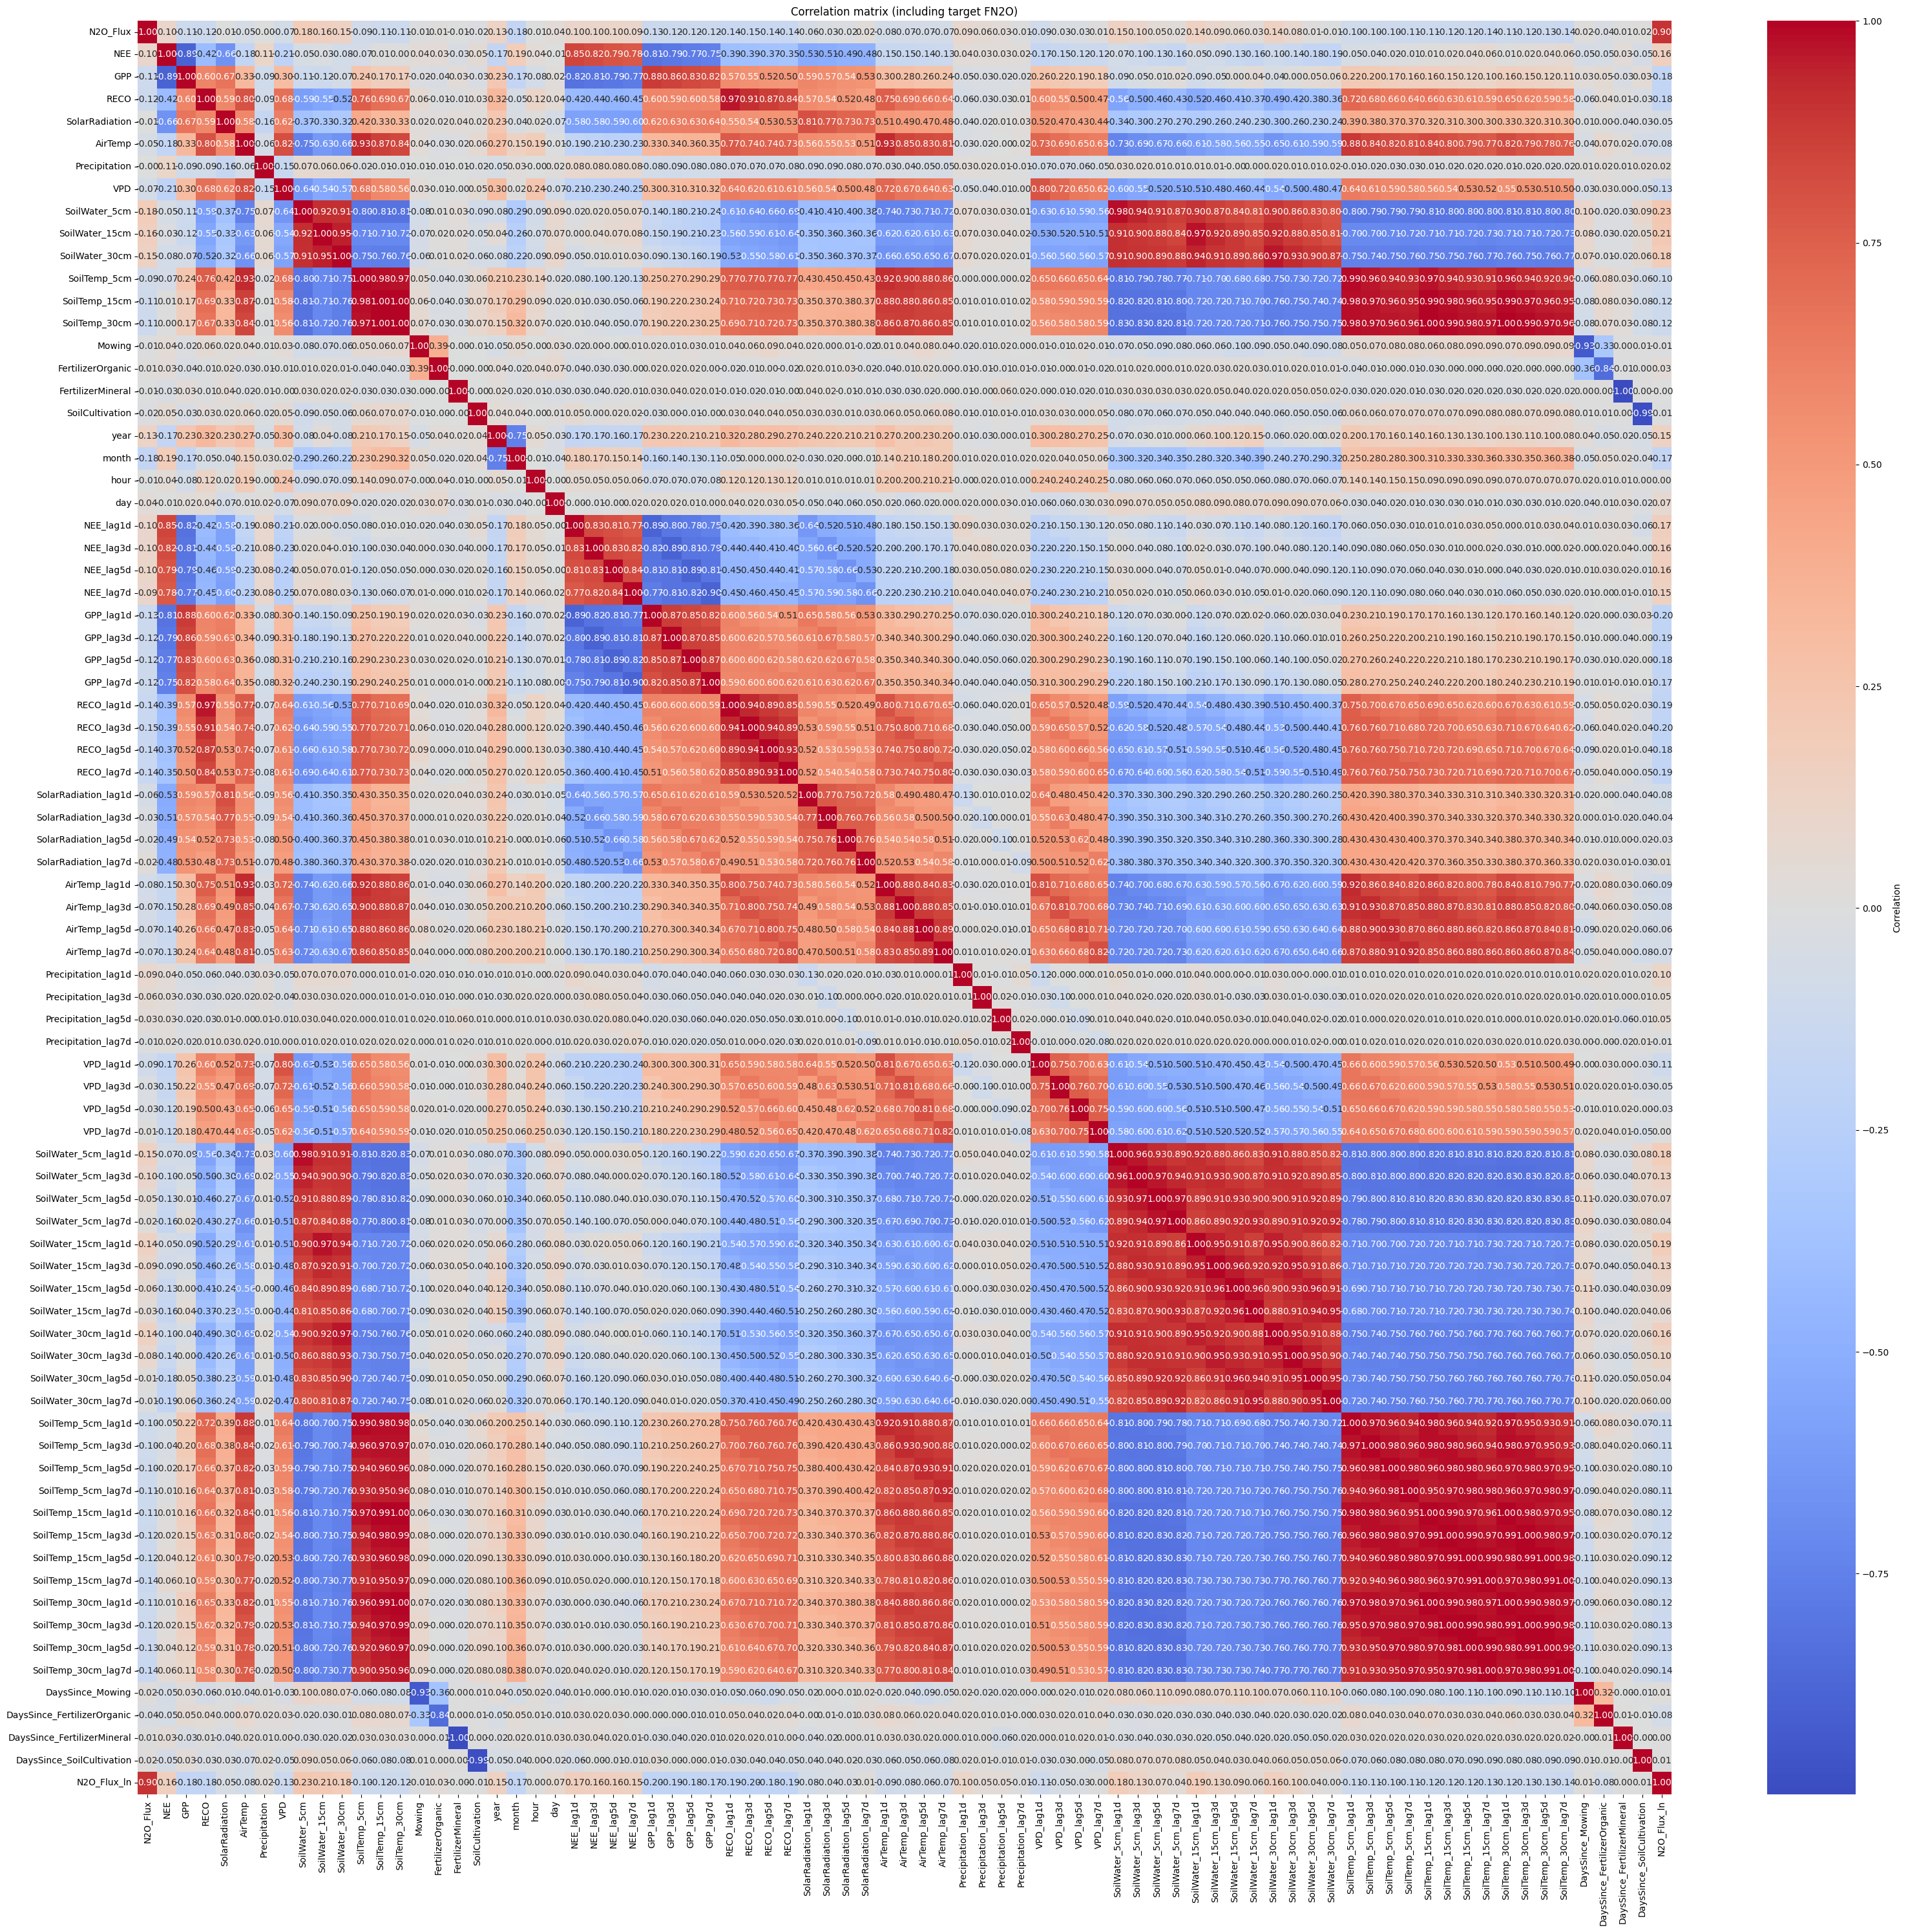

In [40]:
import seaborn as sns
import matplotlib.pyplot as plt

# Compute correlation matrix (Pearson by default)
corr = oensingen_2.corr(numeric_only=True)

plt.figure(figsize=(32,30))
sns.heatmap(
    corr, 
    annot=True, fmt=".2f", cmap="coolwarm",
    cbar_kws={'label': 'Correlation'}
)
plt.title("Correlation matrix (including target FN2O)")
plt.tight_layout()
plt.show()

In [50]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import pandas as pd

def plot_time_series(df, vars_to_plot):
    """
    Plot time series of selected variables with real time gaps shown on the x-axis.
    Automatically formats time labels and adds axis labels.
    """
    df = df.copy().sort_index()

    # --- Ensure datetime index ---
    if not isinstance(df.index, pd.DatetimeIndex):
        df.index = pd.to_datetime(df.index)

    # --- Layout ---
    n_cols = 3
    n_rows = int(len(vars_to_plot) / n_cols) + (len(vars_to_plot) % n_cols > 0)
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 12), sharex=True)
    axes = axes.flatten()

    # --- Plot each variable ---
    for i, var in enumerate(vars_to_plot):
        ax = axes[i]
        ax.plot(df.index, df[var], lw=1)
        ax.set_title(var, fontsize=10)
        ax.set_ylabel(var)
        ax.grid(True, alpha=0.3)

        # Format the x-axis as dates
        ax.xaxis.set_major_locator(mdates.AutoDateLocator())
        ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))
        ax.tick_params(axis='x', rotation=45)

    # --- Remove unused axes if any ---
    for j in range(i + 1, len(axes)):
        fig.delaxes(axes[j])

    # --- Common labels and formatting ---
    fig.suptitle("Time Series", fontsize=14)
    fig.text(0.5, 0.04, "Date", ha='center', fontsize=12)
    fig.tight_layout(rect=[0, 0.05, 1, 0.97])
    plt.show()

Raw Data


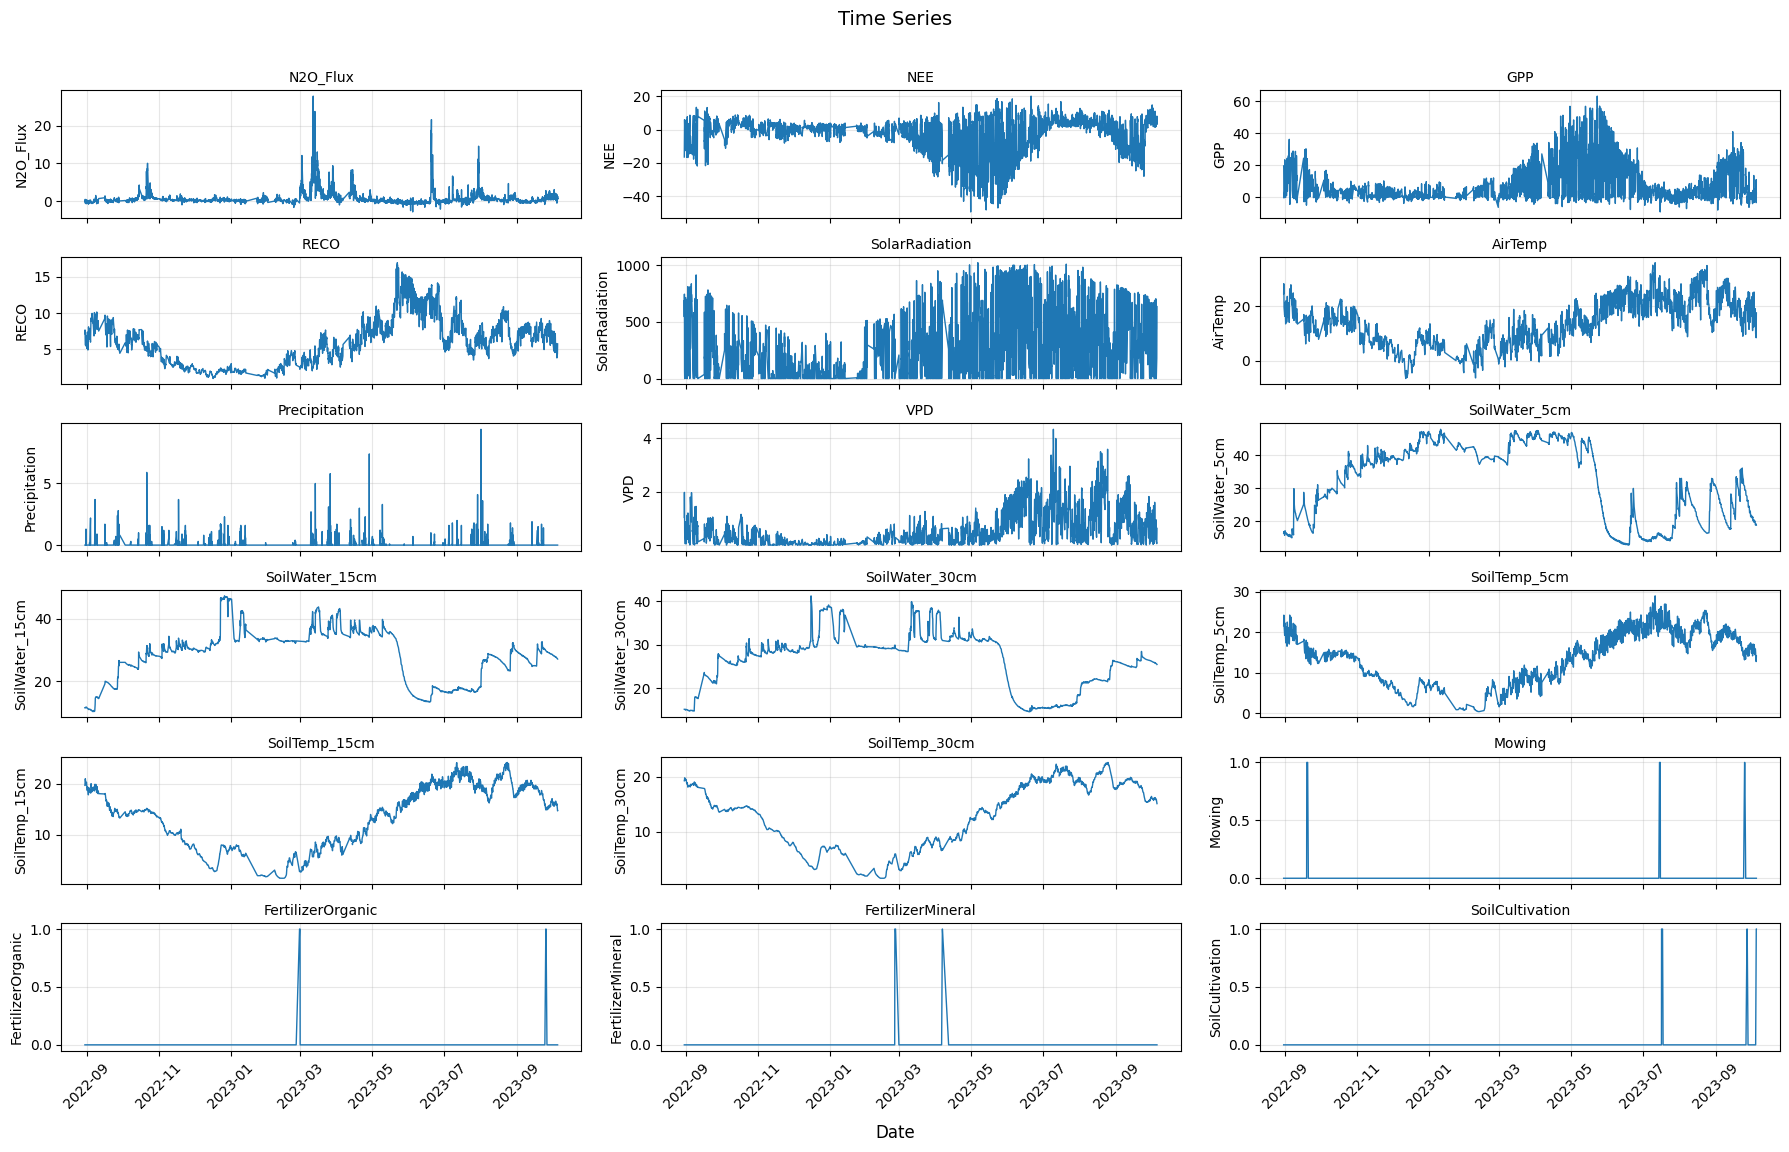

Daily Freq


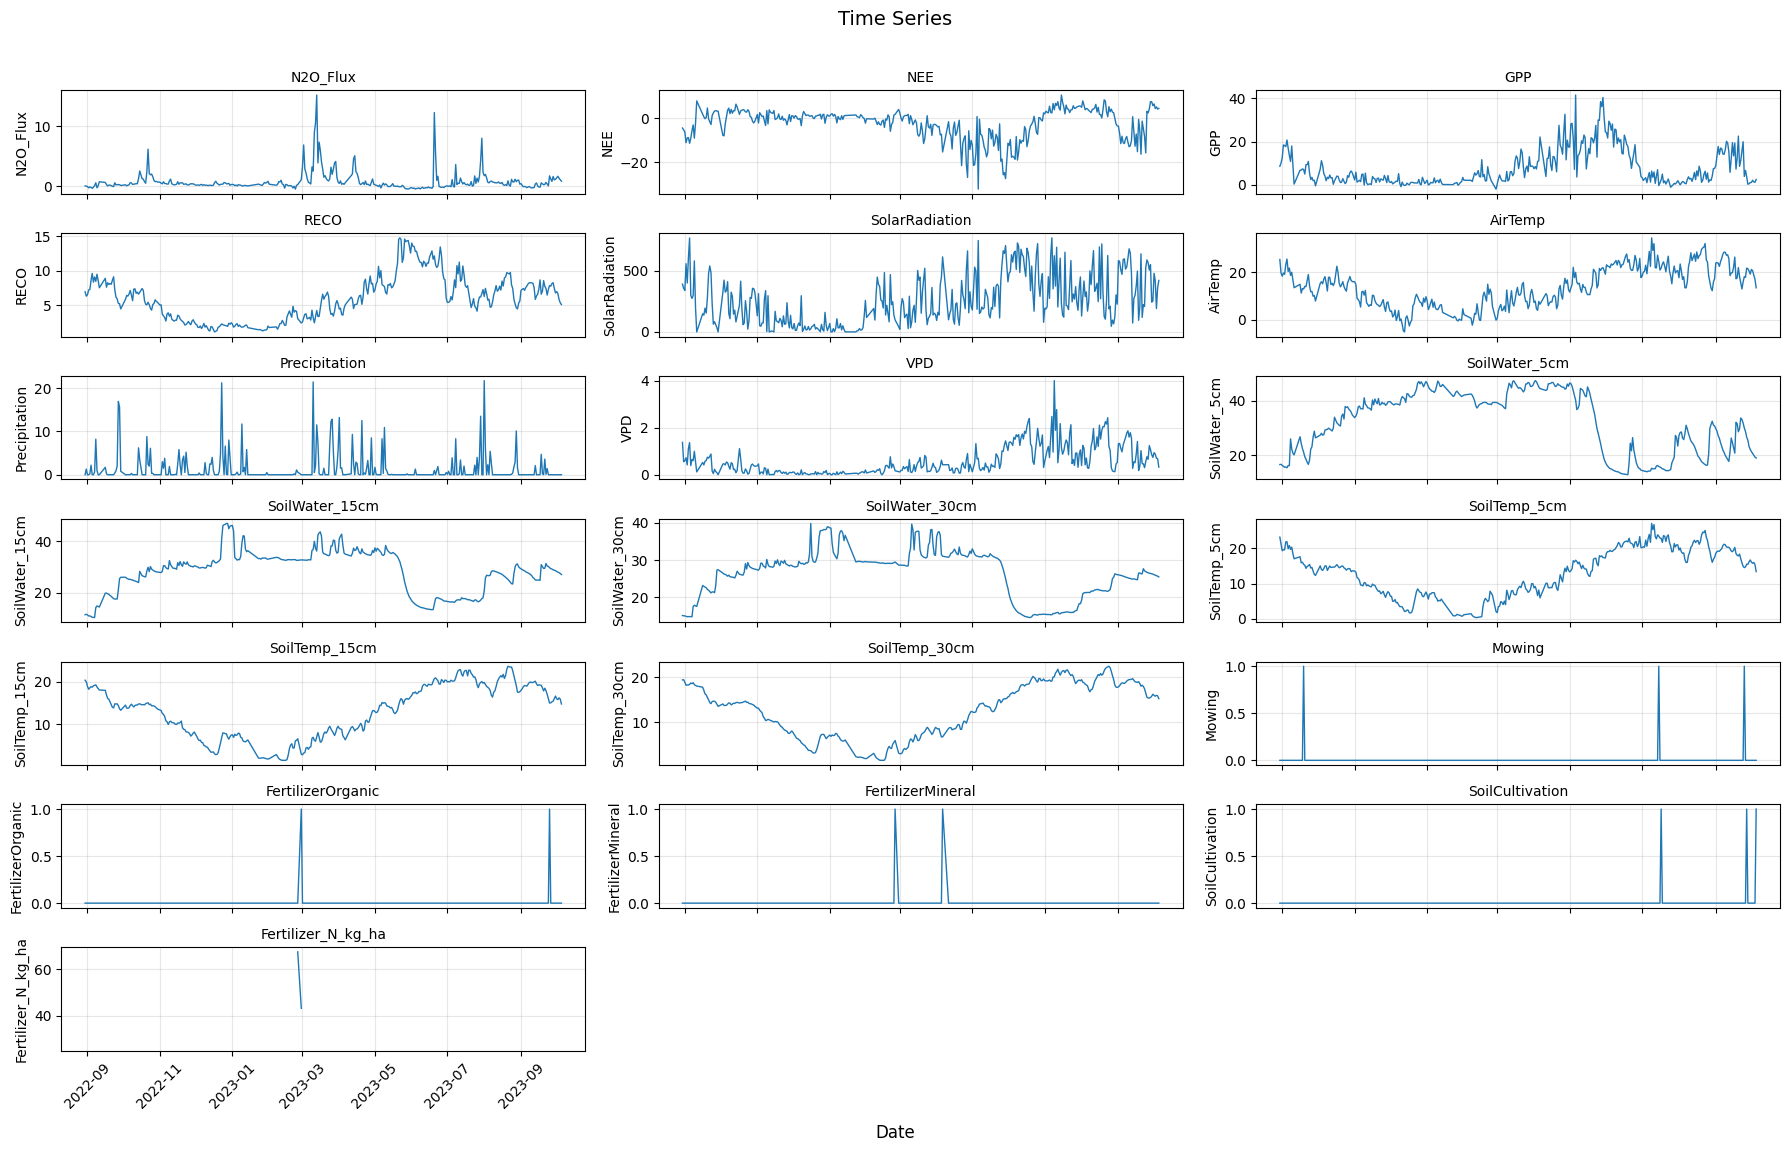

In [51]:
# Variables to plot (excluding Timestamp)
vars_to_plot = [
    "N2O_Flux", "NEE", "GPP", "RECO",
    "SolarRadiation", "AirTemp", "Precipitation",
    "VPD", "SoilWater_5cm", "SoilWater_15cm", "SoilWater_30cm",
    "SoilTemp_5cm", "SoilTemp_15cm", "SoilTemp_30cm",
    "Mowing", "FertilizerOrganic", "FertilizerMineral", "SoilCultivation"
]

# Variables to plot (excluding Timestamp)
vars_to_plot_w_fert = [
    "N2O_Flux", "NEE", "GPP", "RECO",
    "SolarRadiation", "AirTemp", "Precipitation",
    "VPD", "SoilWater_5cm", "SoilWater_15cm", "SoilWater_30cm",
    "SoilTemp_5cm", "SoilTemp_15cm", "SoilTemp_30cm",
    "Mowing", "FertilizerOrganic", "FertilizerMineral", "SoilCultivation", "Fertilizer_N_kg_ha"
]

# Daily averages
print("Raw Data")
plot_time_series(oensingen_2, vars_to_plot)
print("Daily Freq")
plot_time_series(oensingen_2_daily, vars_to_plot_w_fert)

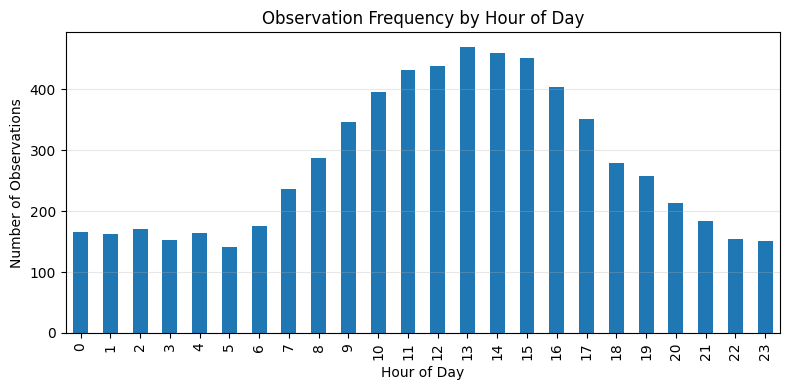

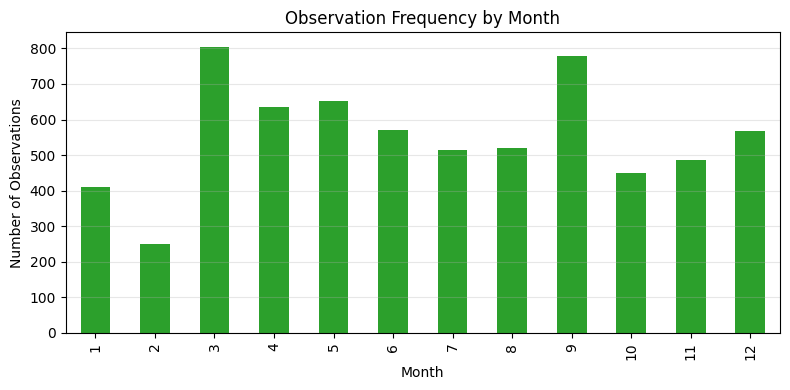

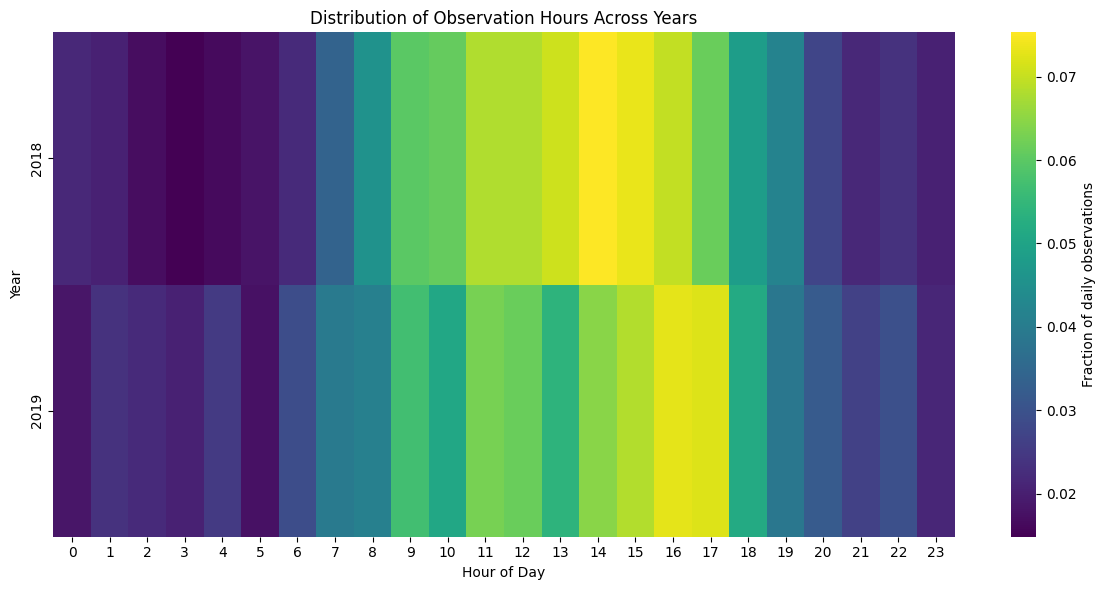

In [43]:
# count observations per hour
hourly_counts = oensingen_2["hour"].value_counts().sort_index()

# plot
plt.figure(figsize=(8,4))
hourly_counts.plot(kind="bar")
plt.xlabel("Hour of Day")
plt.ylabel("Number of Observations")
plt.title("Observation Frequency by Hour of Day")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

# count per month
monthly_counts = oensingen_2["month"].value_counts().sort_index()

# plot
plt.figure(figsize=(8,4))
monthly_counts.plot(kind="bar", color="tab:green")
plt.xlabel("Month")
plt.ylabel("Number of Observations")
plt.title("Observation Frequency by Month")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

# group by year × hour
hour_year_counts = (
    oensingen_1.groupby(["year", "hour"])
    .size()
    .unstack(fill_value=0)
)

# normalize by total per year (to compare proportions)
hour_year_norm = hour_year_counts.div(hour_year_counts.sum(axis=1), axis=0)

# plot as heatmap
plt.figure(figsize=(12,6))
sns.heatmap(hour_year_norm, cmap="viridis", cbar_kws={"label": "Fraction of daily observations"})
plt.xlabel("Hour of Day")
plt.ylabel("Year")
plt.title("Distribution of Observation Hours Across Years")
plt.tight_layout()
plt.show()

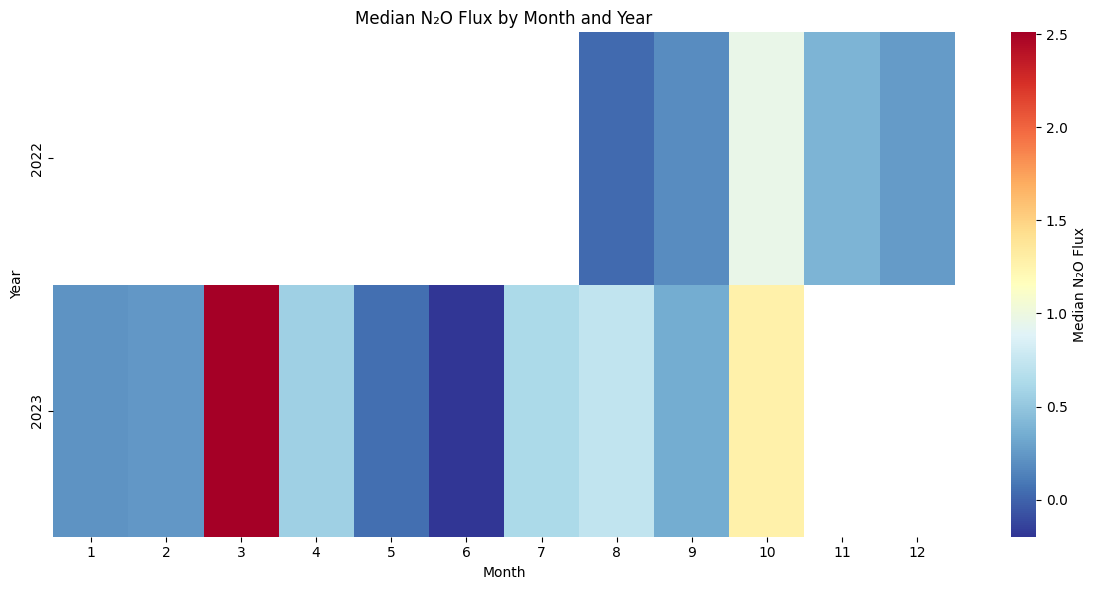

/var/folders/_3/dhm9h5w122sfbk56zms0llk00000gn/T/ipykernel_15136/4261384278.py:39: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  oensingen_2.groupby(["T5_bin", "T15_bin"])["N2O_Flux"]


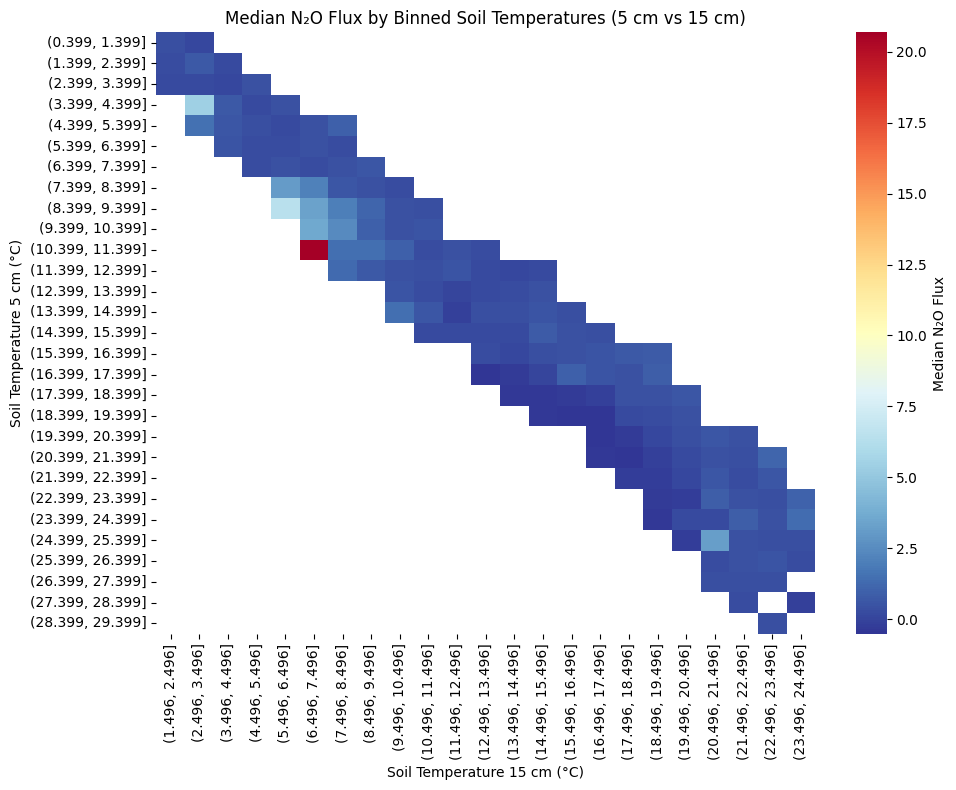

In [44]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# compute median N₂O flux per year × hour
median_flux = (
    oensingen_2.groupby(["year", "month"])["N2O_Flux"]
    .median()
    .unstack(fill_value=np.nan)
)

# plot heatmap
plt.figure(figsize=(12,6))
sns.heatmap(
    median_flux,
    cmap="RdYlBu_r",
    cbar_kws={"label": "Median N₂O Flux"},
)
plt.xlabel("Month")
plt.ylabel("Year")
plt.title("Median N₂O Flux by Month and Year")
plt.tight_layout()
plt.show()

import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# define bin edges for both temperatures
bins_5cm = np.arange(oensingen_2["SoilTemp_5cm"].min(), oensingen_2["SoilTemp_5cm"].max()+1, 1)
bins_15cm = np.arange(oensingen_2["SoilTemp_15cm"].min(), oensingen_2["SoilTemp_15cm"].max()+1, 1)

# create binned categories
oensingen_2["T5_bin"] = pd.cut(oensingen_2["SoilTemp_5cm"], bins=bins_5cm)
oensingen_2["T15_bin"] = pd.cut(oensingen_2["SoilTemp_15cm"], bins=bins_15cm)

# compute median flux per 2D bin
median_flux_binned = (
    oensingen_2.groupby(["T5_bin", "T15_bin"])["N2O_Flux"]
    .median()
    .unstack(fill_value=np.nan)
)

# plot heatmap
plt.figure(figsize=(10,8))
sns.heatmap(
    median_flux_binned,
    cmap="RdYlBu_r",
    cbar_kws={"label": "Median N₂O Flux"},
)
plt.xlabel("Soil Temperature 15 cm (°C)")
plt.ylabel("Soil Temperature 5 cm (°C)")
plt.title("Median N₂O Flux by Binned Soil Temperatures (5 cm vs 15 cm)")
plt.tight_layout()
plt.show()

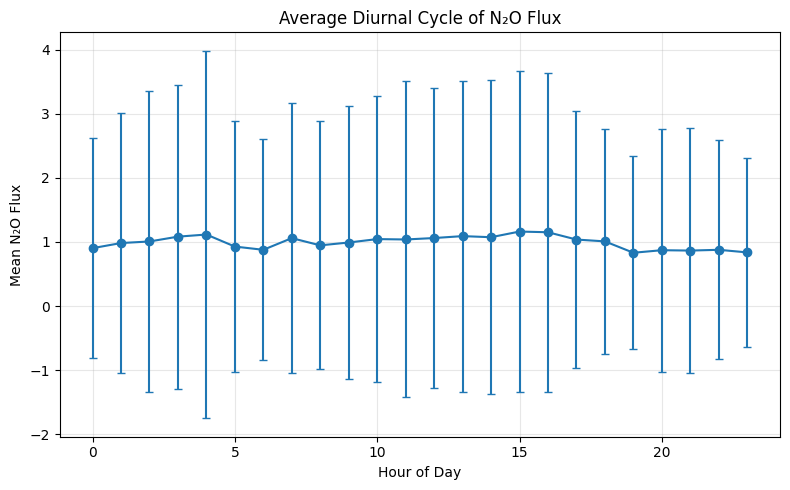

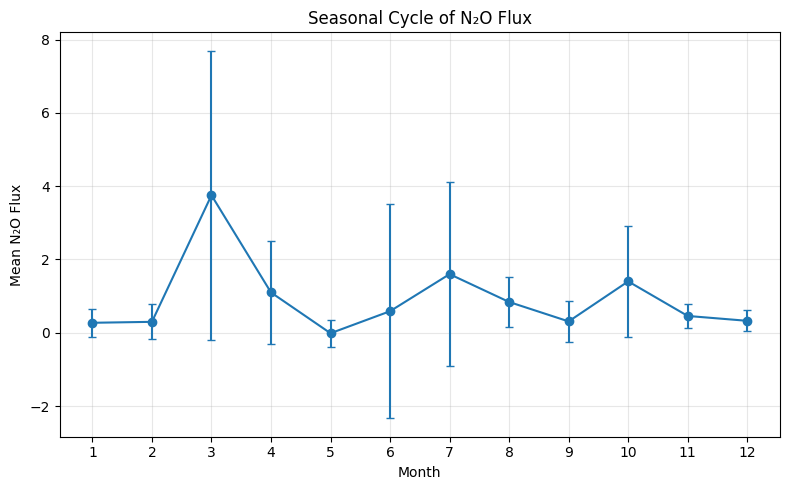

In [45]:
hourly_mean = oensingen_2.groupby("hour")["N2O_Flux"].mean()
hourly_std  = oensingen_2.groupby("hour")["N2O_Flux"].std()

plt.figure(figsize=(8, 5))
plt.errorbar(hourly_mean.index, hourly_mean, yerr=hourly_std, fmt="-o", capsize=3)
plt.xlabel("Hour of Day")
plt.ylabel("Mean N₂O Flux")
plt.title("Average Diurnal Cycle of N₂O Flux")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

monthly_mean = oensingen_2.groupby("month")["N2O_Flux"].mean()
monthly_std  = oensingen_2.groupby("month")["N2O_Flux"].std()

plt.figure(figsize=(8, 5))
plt.errorbar(monthly_mean.index, monthly_mean, yerr=monthly_std, fmt="-o", capsize=3)
plt.xticks(range(1, 13))
plt.xlabel("Month")
plt.ylabel("Mean N₂O Flux")
plt.title("Seasonal Cycle of N₂O Flux")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

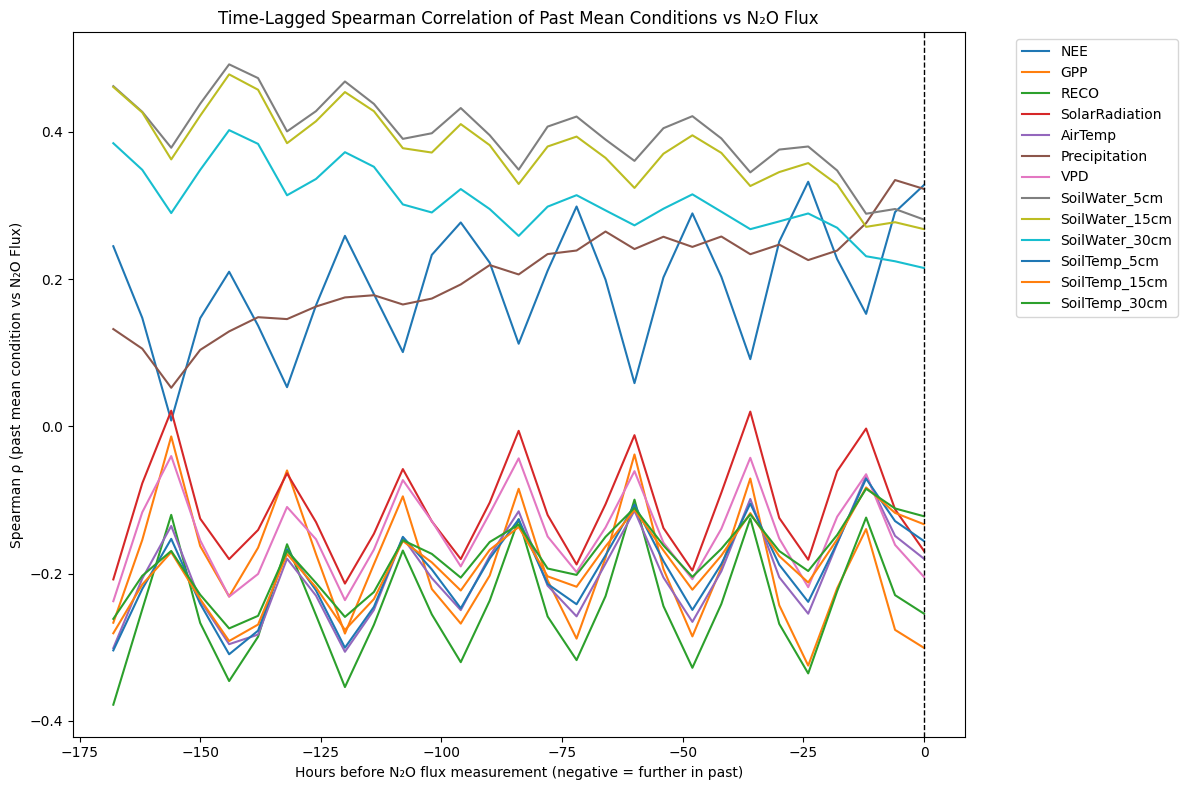

In [46]:
from scipy.stats import spearmanr
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# --- Base setup ---
oensingen_2_time_index = oensingen_2.copy()

predictors = [
    "NEE", "GPP", "RECO",
    "SolarRadiation", "AirTemp", "Precipitation", "VPD",
    "SoilWater_5cm", "SoilWater_15cm", "SoilWater_30cm",
    "SoilTemp_5cm", "SoilTemp_15cm", "SoilTemp_30cm",
]

target = "N2O_Flux"

# --- Parameters ---
window_hours = 24        # window size for averaging (past 24h)
step_hours   = 6        # step between lags
max_hours    = 7 * 24    # look back 1 week (you can extend to 5 weeks)
offsets      = range(0, -max_hours - step_hours, -step_hours)  # only past (0, -24, -48, ...)

# --- Rolling mean of predictors (24h backward window) ---
window = f"{window_hours}h"
rolling_means = oensingen_2_time_index[predictors].rolling(window=window, closed="left").mean()

# --- Compute lag correlations (Spearman) ---
lag_corrs = {}

for var in predictors:
    corrs = []
    for offset in offsets:
        shifted = rolling_means[var].shift(freq=pd.Timedelta(hours=offset))
        aligned = oensingen_2_time_index[[target]].join(shifted.rename("past_mean")).dropna()
        if len(aligned) > 2:
            rho, _ = spearmanr(aligned[target], aligned["past_mean"])
            corrs.append(rho)
        else:
            corrs.append(np.nan)
    lag_corrs[var] = (list(offsets), corrs)

# --- Plot results ---
plt.figure(figsize=(12, 8))
for var, (offsets, corrs) in lag_corrs.items():
    plt.plot(offsets, corrs, label=var)

plt.axvline(0, color="k", linestyle="--", lw=1)
plt.xlabel("Hours before N₂O flux measurement (negative = further in past)")
plt.ylabel("Spearman ρ (past mean condition vs N₂O Flux)")
plt.title("Time-Lagged Spearman Correlation of Past Mean Conditions vs N₂O Flux")
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()

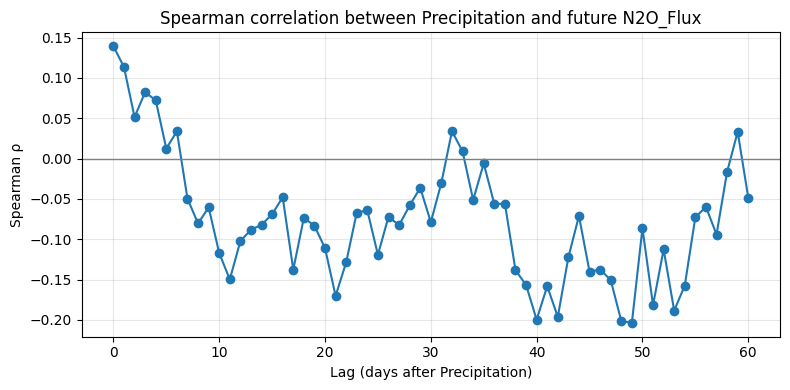

Peak Spearman correlation at lag = 0 days (ρ = 0.139)


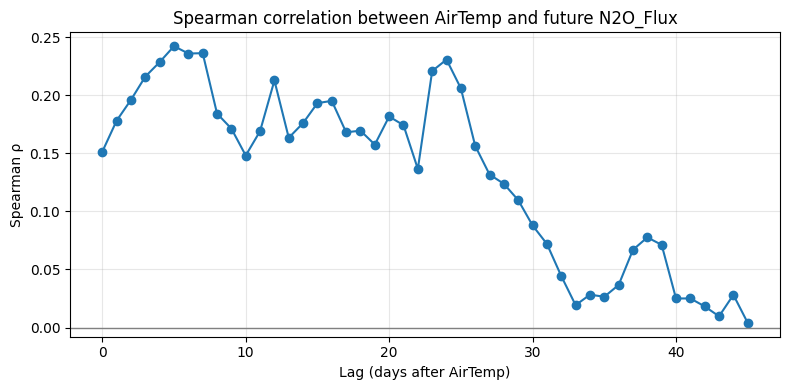

Peak Spearman correlation at lag = 5 days (ρ = 0.242)


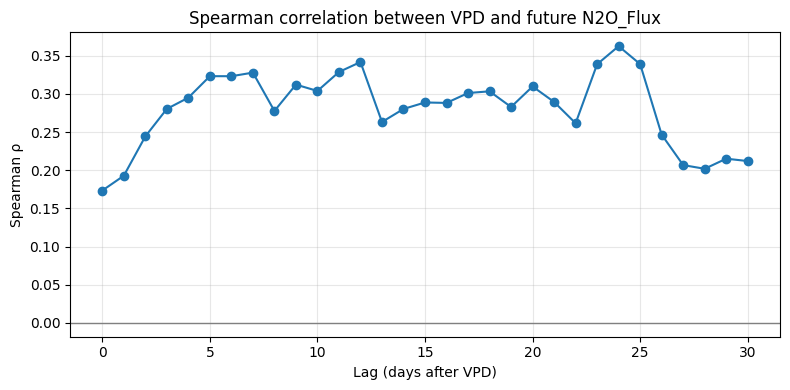

Peak Spearman correlation at lag = 24 days (ρ = 0.363)


In [47]:
from scipy.stats import spearmanr

def plot_lag_correlation(df, col, target="N2O_Flux", max_lag=60, resample_daily=True):
    """
    Compute and plot the Spearman correlation between a predictor and target variable
    over increasing day lags (calendar-based).

    Parameters
    ----------
    df : pd.DataFrame
        DataFrame with a DatetimeIndex.
    col : str
        Column name of the predictor variable (e.g. "Precipitation").
    target : str, optional
        Column name of the target variable, by default "N2O_Flux".
    max_lag : int, optional
        Maximum lag in days, by default 60.
    resample_daily : bool, optional
        If True, resample to daily mean (useful if data is sub-daily).

    Returns
    -------
    pd.DataFrame
        DataFrame with 'lag' and 'spearman_r' for each lag.
    """

    # --- Ensure datetime index ---
    df = df.copy()
    if not isinstance(df.index, pd.DatetimeIndex):
        df.index = pd.to_datetime(df.index)

    # --- Optional daily resampling ---
    if resample_daily:
        df = df.select_dtypes(include=[np.number]).resample("D").mean()

    # --- Filter for valid positive flux values ---
    df = df[df[target] >= 0][[col, target]].dropna(subset=[target])

    # --- Compute lag correlations ---
    lags = np.arange(0, max_lag + 1)
    corrs = []

    for lag in lags:
        shifted = df[col].shift(freq=pd.to_timedelta(lag, unit="D"))
        aligned = pd.concat([df[target], shifted], axis=1, join="inner").dropna()

        if aligned.empty:
            corrs.append(np.nan)
        else:
            r, _ = spearmanr(aligned[target], aligned[col])
            corrs.append(r)

    # --- Store results ---
    result = pd.DataFrame({"lag_days": lags, "spearman_r": corrs})

    # --- Plot ---
    plt.figure(figsize=(8, 4))
    plt.plot(result["lag_days"], result["spearman_r"], marker="o", color="tab:blue")
    plt.axhline(0, color="gray", lw=1)
    plt.xlabel(f"Lag (days after {col})")
    plt.ylabel("Spearman ρ")
    plt.title(f"Spearman correlation between {col} and future {target}")
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

    # --- Report peak correlation ---
    best_lag = result["lag_days"].iloc[np.nanargmax(result["spearman_r"])]
    best_r = np.nanmax(result["spearman_r"])
    print(f"Peak Spearman correlation at lag = {best_lag} days (ρ = {best_r:.3f})")

plot_lag_correlation(oensingen_2, col="Precipitation", max_lag=60)
plot_lag_correlation(oensingen_2, col="AirTemp", max_lag=45)
plot_lag_correlation(oensingen_2, col="VPD", max_lag=30)

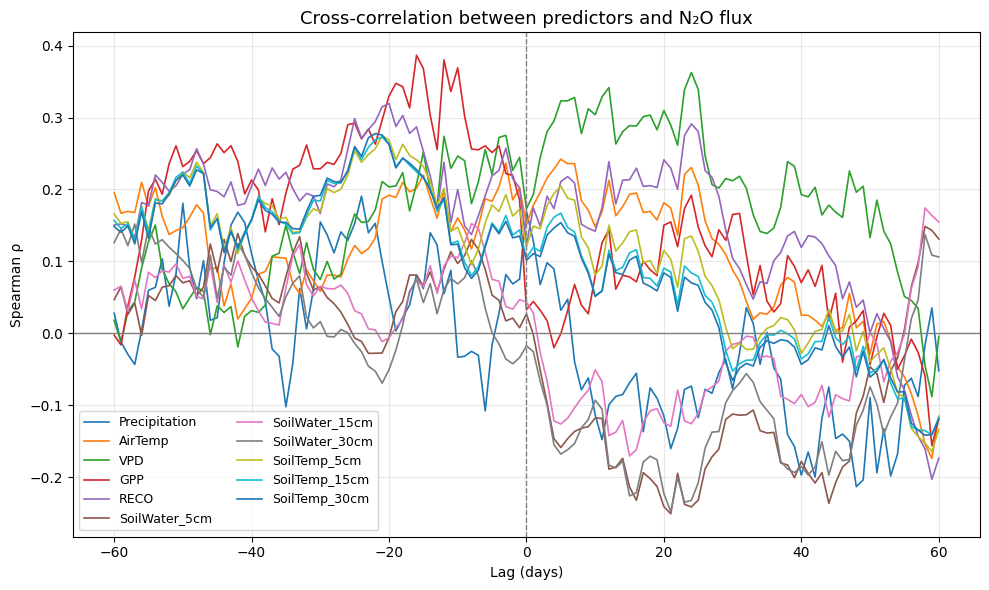

          Variable  Best lag (days)  Max corr (ρ)
3              GPP              -16         0.387
2              VPD               24         0.363
4             RECO              -20         0.319
10   SoilTemp_30cm              -22         0.278
8     SoilTemp_5cm              -21         0.275
9    SoilTemp_15cm              -21         0.273
5    SoilWater_5cm               21        -0.251
7   SoilWater_30cm               21        -0.248
1          AirTemp                5         0.242
0    Precipitation               48        -0.213
6   SoilWater_15cm               58         0.174


In [48]:
def cross_correlation_single(df, predictor_vars, target="N2O_Flux", max_lag=60):
    df = df.copy()
    if not isinstance(df.index, pd.DatetimeIndex):
        if "Date" in df.columns:
            df["Date"] = pd.to_datetime(df["Date"])
            df = df.set_index("Date")
        else:
            raise ValueError("DataFrame must have a DatetimeIndex or 'Date' column")

    df = df[df[target] >= 0].dropna(subset=[target])
    numeric_cols = df.select_dtypes(include=[np.number]).columns
    predictor_vars = [v for v in predictor_vars if v in numeric_cols]
    lags = np.arange(-max_lag, max_lag + 1)
    
    # Sort by index
    df = df.sort_index()
    corrs_dict = {}

    # Compute correlations for each predictor
    for var in predictor_vars:
        corrs = []
        for lag in lags:
            shifted = df[var].shift(freq=pd.to_timedelta(lag, unit="D"))
            aligned = pd.concat([df[target], shifted], axis=1, join="inner").dropna()
            rho = np.nan if aligned.empty else spearmanr(aligned[target], aligned[var])[0]
            corrs.append(rho)
        corrs_dict[var] = corrs

    # Plot
    fig, ax = plt.subplots(figsize=(10, 6))
    
    for var, corrs in corrs_dict.items():
        ax.plot(lags, corrs, lw=1.2, label=var)

    ax.axhline(0, color="gray", lw=1)
    ax.axvline(0, color="gray", lw=1, ls="--")
    ax.set_xlabel("Lag (days)")
    ax.set_ylabel("Spearman ρ")
    ax.set_title("Cross-correlation between predictors and N₂O flux", fontsize=13)
    ax.grid(True, alpha=0.3)
    ax.legend(loc="best", ncol=2, fontsize=9)
    plt.tight_layout()
    plt.show()

    # --- Summary ---
    summary_rows = []
    for var, corrs in corrs_dict.items():
        best_idx = np.nanargmax(np.abs(corrs))
        summary_rows.append({
            "Variable": var,
            "Best lag (days)": int(lags[best_idx]),
            "Max corr (ρ)": corrs[best_idx],
        })

    summary_df = pd.DataFrame(summary_rows)
    summary_df = (
        summary_df
        .sort_values(
            by="Max corr (ρ)",
            ascending=False,
            key=lambda col: np.abs(col) if col.name == "Max corr (ρ)" else col
        )
        .round(3)
    )

    return summary_df

predictors = [
    "Precipitation", "AirTemp", "VPD", "GPP", "RECO",
    "SoilWater_5cm", "SoilWater_15cm", "SoilWater_30cm",
    "SoilTemp_5cm", "SoilTemp_15cm", "SoilTemp_30cm"
]

summary = cross_correlation_single(oensingen_2_daily, predictor_vars=predictors, max_lag=60)
print(summary)

Found 3 fertilization events


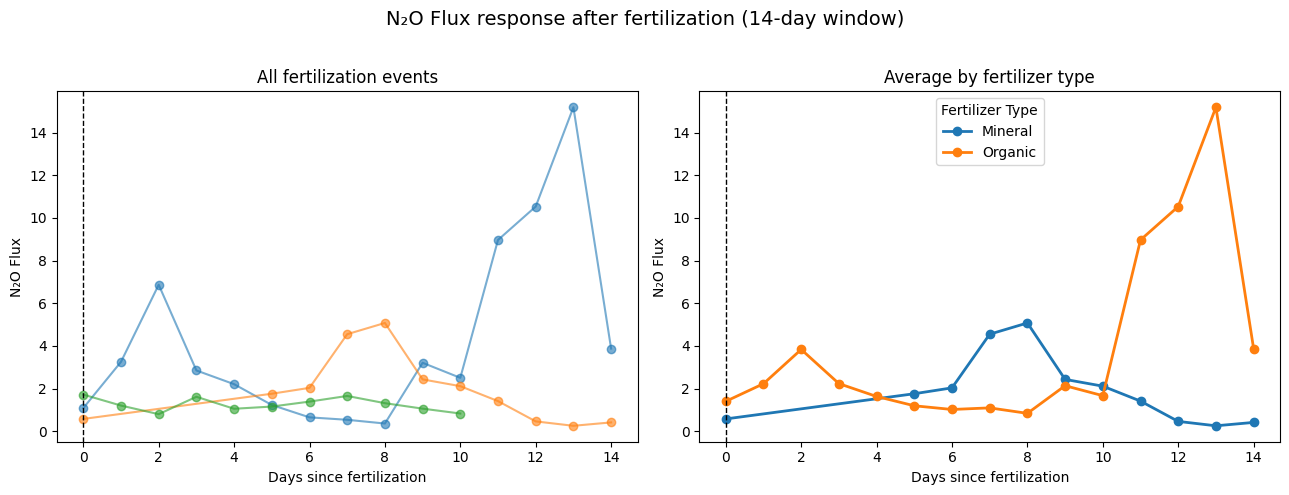

In [49]:
import matplotlib.pyplot as plt
import pandas as pd

# --- Identify fertilization events ---
fert_events = oensingen_2_daily[
    (oensingen_2_daily["FertilizerOrganic"] == 1) |
    (oensingen_2_daily["FertilizerMineral"] == 1)
].copy()

# Date is already the index, so we'll work with that
print(f"Found {len(fert_events)} fertilization events")

# --- Extract N₂O fluxes for 14 days after each event ---
window_days = 14
records = []

for event_date, event in fert_events.iterrows():
    # event_date is already a datetime since it's the index
    subset = oensingen_2_daily[
        (oensingen_2_daily.index >= event_date) &
        (oensingen_2_daily.index <= event_date + pd.Timedelta(days=window_days))
    ].copy()
    
    subset["days_since_fert"] = (subset.index - event_date).days
    subset["event_date"] = event_date
    subset["fert_type"] = (
        "Organic" if event["FertilizerOrganic"] == 1 else "Mineral"
    )
    records.append(subset)

fert_windows = pd.concat(records, ignore_index=False)

# --- Plot setup (1x2 grid) ---
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle("N₂O Flux response after fertilization (14-day window)", fontsize=14)

# --- Panel 1: All individual events ---
for event_date, group in fert_windows.groupby("event_date"):
    axes[0].plot(group["days_since_fert"], group["N2O_Flux"], marker="o", alpha=0.6)

axes[0].axvline(0, color="black", linestyle="--", linewidth=1)
axes[0].set_title("All fertilization events")
axes[0].set_xlabel("Days since fertilization")
axes[0].set_ylabel("N₂O Flux")

# --- Panel 2: Average by fertilizer type ---
for fert_type, group in fert_windows.groupby("fert_type"):
    mean_curve = group.groupby("days_since_fert")["N2O_Flux"].mean()
    axes[1].plot(mean_curve.index, mean_curve.values, marker="o", label=fert_type, linewidth=2)

axes[1].axvline(0, color="black", linestyle="--", linewidth=1)
axes[1].set_title("Average by fertilizer type")
axes[1].set_xlabel("Days since fertilization")
axes[1].set_ylabel("N₂O Flux")
axes[1].legend(title="Fertilizer Type")

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

/var/folders/_3/dhm9h5w122sfbk56zms0llk00000gn/T/ipykernel_15136/2779555004.py:117: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0.07, 1, 0.96])


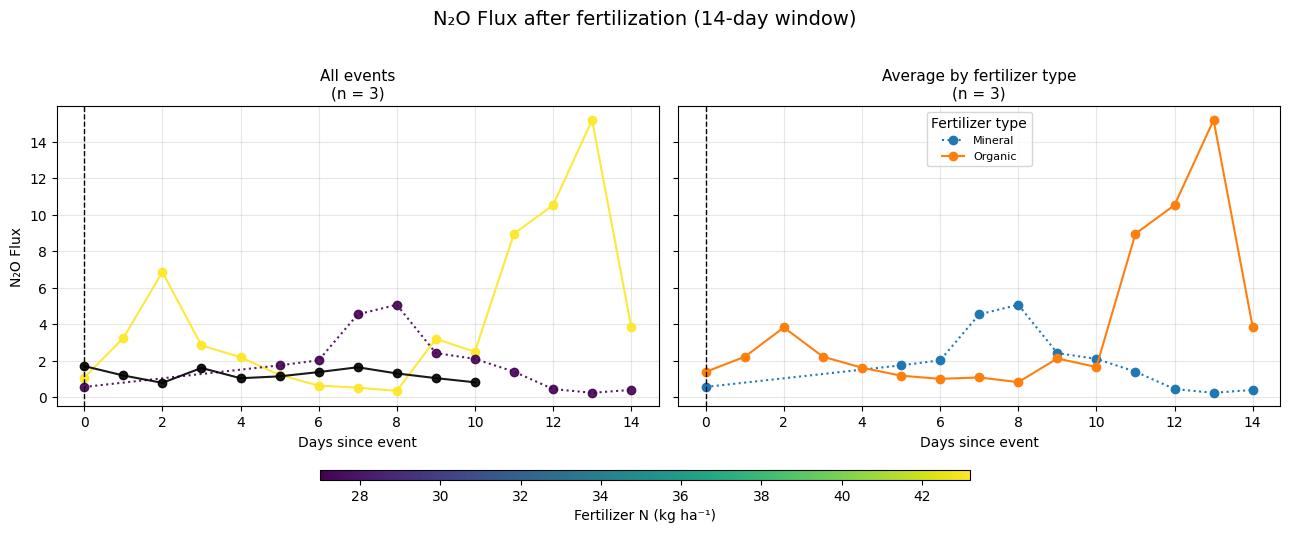

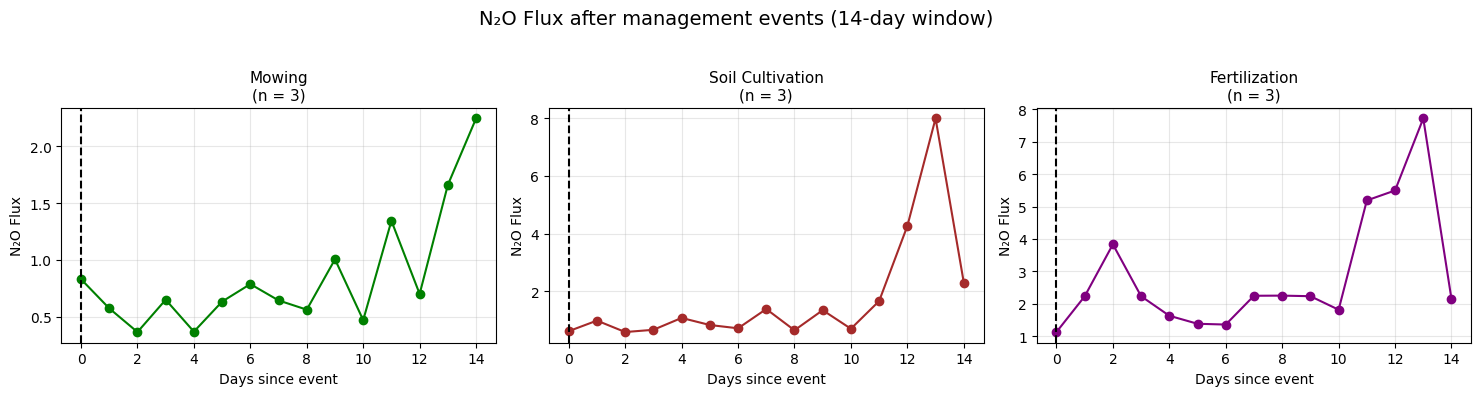

In [50]:
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.colors as mcolors
import numpy as np
import pandas as pd

# ==========================================================
# 1️⃣ Helper: extract N₂O flux windows after each management event
# ==========================================================
def extract_event_windows(df_daily, event_col, window_days=14):
    """
    Extract N₂O flux time windows following a management event.

    Args:
        df_daily : daily dataframe (must have Date as index, N2O_Flux, and event_col)
        event_col : column name for event (e.g., "Mowing")
        window_days : number of days after event to include
    """
    records = []
    events = df_daily[df_daily[event_col] == 1].copy()
    if events.empty:
        return pd.DataFrame()

    for event_date, event in events.iterrows():
        subset = df_daily[
            (df_daily.index >= event_date) &
            (df_daily.index <= event_date + pd.Timedelta(days=window_days))
        ].copy()

        subset["days_since_event"] = (subset.index - event_date).days
        subset["event_date"] = event_date
        subset["event_type"] = event_col  # keep event label
        records.append(subset)

    return pd.concat(records, ignore_index=False)


# ==========================================================
# 2️⃣ Create windows for each management type
# ==========================================================
mow_windows   = extract_event_windows(oensingen_2_daily, "Mowing")
cult_windows  = extract_event_windows(oensingen_2_daily, "SoilCultivation")
fert_windows  = extract_event_windows(oensingen_2_daily, "FertilizerOrganic")
fert_windowsM = extract_event_windows(oensingen_2_daily, "FertilizerMineral")

# merge organic + mineral
fert_windows["event_type"] = "Organic"
fert_windowsM["event_type"] = "Mineral"
fert_windows = pd.concat([fert_windows, fert_windowsM], ignore_index=False)

# Add fertilizer amount (if available)
if "Fertilizer_N_kg_ha" not in fert_windows.columns:
    fert_windows["Fertilizer_N_kg_ha"] = 0.0

# ==========================================================
# 3️⃣ Fertilization plots
# ==========================================================
fig, axes = plt.subplots(1, 2, figsize=(13, 5), sharey=True)
fig.suptitle("N₂O Flux after fertilization (14-day window)", fontsize=14)

# normalize fertilizer N for color mapping
norm = mcolors.Normalize(
    vmin=fert_windows["Fertilizer_N_kg_ha"].min(),
    vmax=fert_windows["Fertilizer_N_kg_ha"].max()
)
cmap = cm.viridis


def plot_fert_events(ax, df, title):
    if df.empty:
        ax.set_title(f"{title}\n(no events)", fontsize=10)
        return

    n_total = df["event_date"].nunique()

    for event_date, group in df.groupby("event_date"):
        n_val = group["Fertilizer_N_kg_ha"].iloc[0]
        fert_type = group["event_type"].iloc[0]
        color = cmap(norm(n_val))
        linestyle = "-" if "Organic" in fert_type else ":"
        ax.plot(
            group["days_since_event"], group["N2O_Flux"],
            color=color, linestyle=linestyle, marker="o", alpha=0.9
        )

    ax.axvline(0, color="black", linestyle="--", linewidth=1)
    ax.set_title(f"{title}\n(n = {n_total})", fontsize=11)
    ax.set_xlabel("Days since event")
    ax.set_ylabel("N₂O Flux")
    ax.grid(True, alpha=0.3)


# (a) All events
plot_fert_events(axes[0], fert_windows, "All events")

# (b) Average by fertilizer type
ax = axes[1]
for event_type, group in fert_windows.groupby("event_type"):
    mean_curve = group.groupby("days_since_event")["N2O_Flux"].mean()
    linestyle = "-" if "Organic" in event_type else ":"
    ax.plot(mean_curve.index, mean_curve.values,
            marker="o", label=event_type, linestyle=linestyle)
n_total = fert_windows["event_date"].nunique()

ax.axvline(0, color="black", linestyle="--", linewidth=1)
ax.set_title(f"Average by fertilizer type\n(n = {n_total})", fontsize=11)
ax.set_xlabel("Days since event")
ax.legend(title="Fertilizer type", fontsize=8)
ax.grid(True, alpha=0.3)

# colorbar
cbar_ax = fig.add_axes([0.25, 0.04, 0.5, 0.02])
sm = cm.ScalarMappable(norm=norm, cmap=cmap)
cbar = fig.colorbar(sm, cax=cbar_ax, orientation="horizontal")
cbar.set_label("Fertilizer N (kg ha⁻¹)")

plt.tight_layout(rect=[0, 0.07, 1, 0.96])
plt.show()

# ==========================================================
# 4️⃣ Management event plots
# ==========================================================
fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=False)
fig.suptitle("N₂O Flux after management events (14-day window)", fontsize=14)

management_panels = [
    (mow_windows, "Mowing", "green"),
    (cult_windows, "Soil Cultivation", "brown"),
    (fert_windows, "Fertilization", "purple")
]

for ax, (df, label, color) in zip(axes, management_panels):
    if df.empty:
        ax.set_title(f"{label}\n(no events)", fontsize=10)
        continue

    n_total = df["event_date"].nunique()

    mean_curve = df.groupby("days_since_event")["N2O_Flux"].mean()
    ax.plot(
        mean_curve.index, mean_curve.values,
        marker="o", color=color, linestyle="-"
    )

    ax.axvline(0, color="black", linestyle="--")
    ax.set_title(f"{label}\n(n = {n_total})", fontsize=11)
    ax.set_xlabel("Days since event")
    ax.set_ylabel("N₂O Flux")
    ax.grid(True, alpha=0.3)

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

# PCA plots

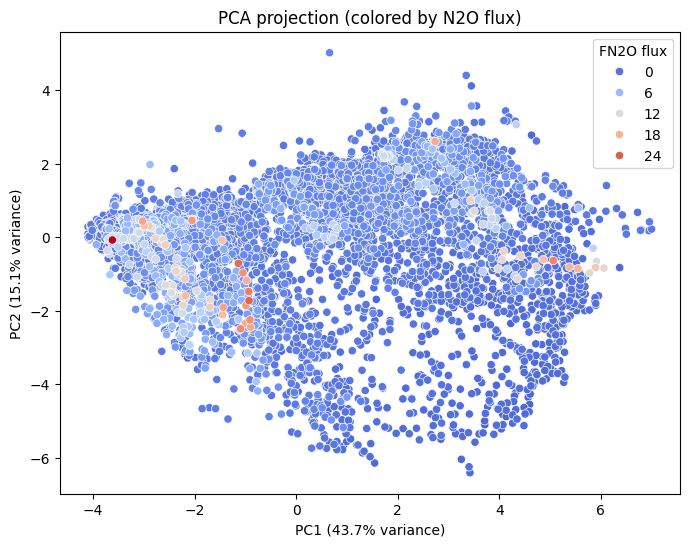

In [14]:
oensingen_2_clean = oensingen_2.dropna()
oensingen_2_clean = oensingen_2_clean.sort_values(
    by="N2O_Flux",
    ascending=True  # ascending puts zeros first, descending puts them last
)

X_2 = oensingen_2_clean.drop(columns=["N2O_Flux", "Timestamp", "time_diff", "Date"])
y_2 = oensingen_2_clean["N2O_Flux"]

from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import seaborn as sns

# Standardize predictors
X_scaled_2 = StandardScaler().fit_transform(X_2)

# Run PCA (2 components for visualization)
pca_2 = PCA(n_components=2)
X_pca_2 = pca_2.fit_transform(X_scaled_2)

# Create DataFrame for plotting
pca_df_2 = pd.DataFrame(X_pca_2, columns=['PC1', 'PC2'])
pca_df_2["FN2O"] = y_2.values

# Scatter plot
plt.figure(figsize=(8,6))
sns.scatterplot(data=pca_df_2, x="PC1", y="PC2", hue="FN2O", palette="coolwarm")
plt.title("PCA projection (colored by N2O flux)")
plt.xlabel(f"PC1 ({pca_2.explained_variance_ratio_[0]*100:.1f}% variance)")
plt.ylabel(f"PC2 ({pca_2.explained_variance_ratio_[1]*100:.1f}% variance)")
plt.legend(title="FN2O flux", loc="best")
plt.show()

In [39]:
loadings = pd.DataFrame(
    pca_2.components_.T,
    index=X_2.columns,
    columns=["PC1", "PC2"]
)
print(loadings.sort_values("PC1", ascending=False))

                        PC1       PC2
SoilTemp_5cm       0.346798  0.087993
AirTemp            0.341171 -0.026435
SoilTemp_15cm      0.334896  0.146334
SoilTemp_30cm      0.331780  0.150520
RECO               0.303709 -0.201747
VPD                0.287503 -0.096598
SolarRadiation     0.215587 -0.402537
GPP                0.139924 -0.530525
SoilCultivation    0.027394  0.055692
Mowing             0.024060  0.051282
FertilizerMineral -0.006779 -0.047263
FertilizerOrganic -0.008062  0.022326
Precipitation     -0.033997  0.107388
NEE               -0.078321  0.572483
SoilWater_15cm    -0.301726 -0.174242
SoilWater_30cm    -0.307155 -0.208803
SoilWater_5cm     -0.325628 -0.179643


/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: invalid value encountered in log1p
  result = getattr(ufunc, method)(*inputs, **kwargs)


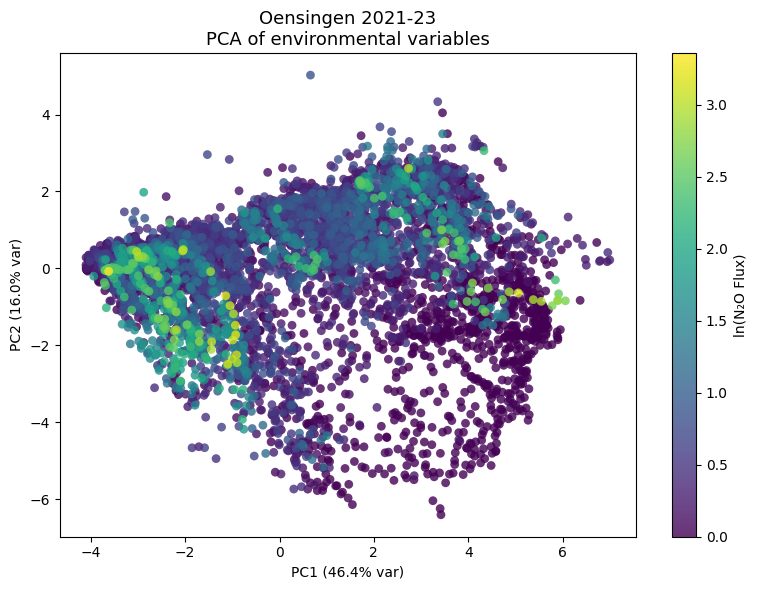

In [15]:
import matplotlib.cm as cm

# --- transformation ---
oensingen_2_clean["N2O_Flux_ln"] = np.where(
    oensingen_2_clean["N2O_Flux"] > 0,
    np.log1p(oensingen_2_clean["N2O_Flux"]),
    0
)

# =============================================
# 1️⃣ Define variables and plotting function
# =============================================
base_vars = [
    "Precipitation", "SolarRadiation", "AirTemp", "VPD",
    "SoilWater_5cm", "SoilWater_15cm", "SoilWater_30cm",
    "SoilTemp_5cm", "SoilTemp_15cm", "SoilTemp_30cm",
    "NEE", "GPP", "RECO", "Mowing", "FertilizerMineral", "SoilCultivation"
]

def plot_pca(df, title):
    # Drop rows with missing values in required columns
    df_clean = df.dropna(subset=base_vars + ["N2O_Flux_ln"]).copy()
    
    # Standardize variables
    X_scaled = StandardScaler().fit_transform(df_clean[base_vars])
    
    # Run PCA
    pca = PCA(n_components=2)
    pcs = pca.fit_transform(X_scaled)
    df_clean["PC1"] = pcs[:, 0]
    df_clean["PC2"] = pcs[:, 1]

    # Sort by N2O_Flux (so larger appear on top)
    df_clean = df_clean.sort_values("N2O_Flux_ln", ascending=True)

    # Plot
    fig, ax = plt.subplots(figsize=(8, 6))
    sc = ax.scatter(
        df_clean["PC1"], df_clean["PC2"],
        c=df_clean["N2O_Flux_ln"],
        cmap=cm.viridis,
        s=40, alpha=0.8, edgecolor="none"
    )

    # Labels and aesthetics
    ax.set_title(f"{title}\nPCA of environmental variables", fontsize=13)
    ax.set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% var)")
    ax.set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% var)")
    cbar = plt.colorbar(sc, ax=ax)
    cbar.set_label("ln(N₂O Flux)")
    plt.tight_layout()
    plt.show()

# =============================================
# 2️⃣ Run for oensingen 2021-23
# =============================================
plot_pca(oensingen_2_clean, "Oensingen 2021-23")

# UMAP plots

/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


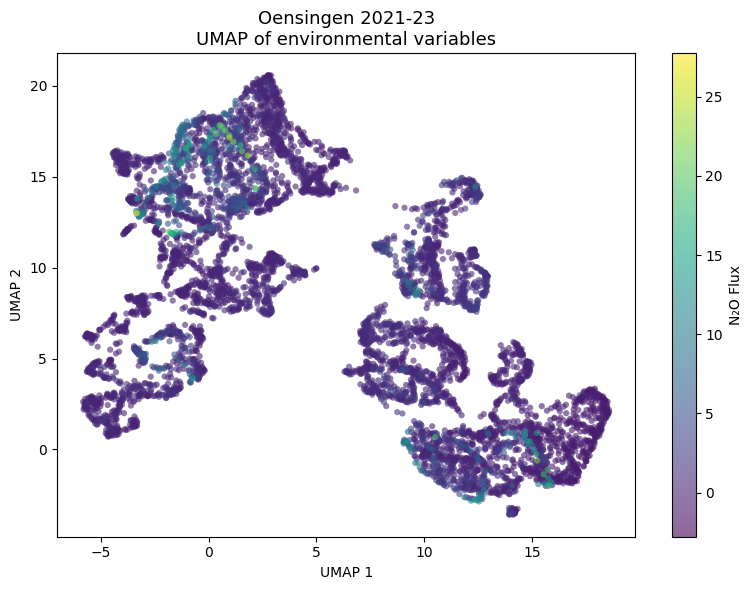

In [21]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
import umap
import matplotlib.cm as cm

# =============================================
# 1️⃣ Define variables and plotting function
# =============================================
base_vars = [
    "Precipitation", "SolarRadiation", "AirTemp", "VPD",
    "SoilWater_5cm", "SoilWater_15cm", "SoilWater_30cm",
    "SoilTemp_5cm", "SoilTemp_15cm", "SoilTemp_30cm",
    "NEE", "GPP", "RECO", "Mowing", "FertilizerMineral", "SoilCultivation"
]


def plot_umap(df, title, n_neighbors=50, min_dist=0.5, random_state=42):
    # Drop rows with missing values
    df_clean = df.dropna(subset=base_vars + ["N2O_Flux"]).copy()

    # Standardize
    X_scaled = StandardScaler().fit_transform(df_clean[base_vars])

    # Run UMAP
    reducer = umap.UMAP(
        n_components=2,
        n_neighbors=n_neighbors,
        min_dist=min_dist,
        metric="euclidean",
        random_state=random_state
    )
    embedding = reducer.fit_transform(X_scaled)
    df_clean["UMAP1"] = embedding[:, 0]
    df_clean["UMAP2"] = embedding[:, 1]

    # Sort by N2O_Flux so high values are plotted last (on top)
    df_clean = df_clean.sort_values("N2O_Flux", ascending=True)

    # Plot
    fig, ax = plt.subplots(figsize=(8, 6))
    sc = ax.scatter(
        df_clean["UMAP1"], df_clean["UMAP2"],
        c=df_clean["N2O_Flux"],
        cmap=cm.viridis,
        s=20, alpha=0.6, edgecolor="none"
    )

    ax.set_title(f"{title}\nUMAP of environmental variables", fontsize=13)
    ax.set_xlabel("UMAP 1")
    ax.set_ylabel("UMAP 2")
    cbar = plt.colorbar(sc, ax=ax)
    cbar.set_label("N₂O Flux")
    plt.tight_layout()
    plt.show()

# =============================================
# 2️⃣ Run for Oensingen 2021-23
# =============================================
plot_umap(oensingen_2_clean, "Oensingen 2021-23")

/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


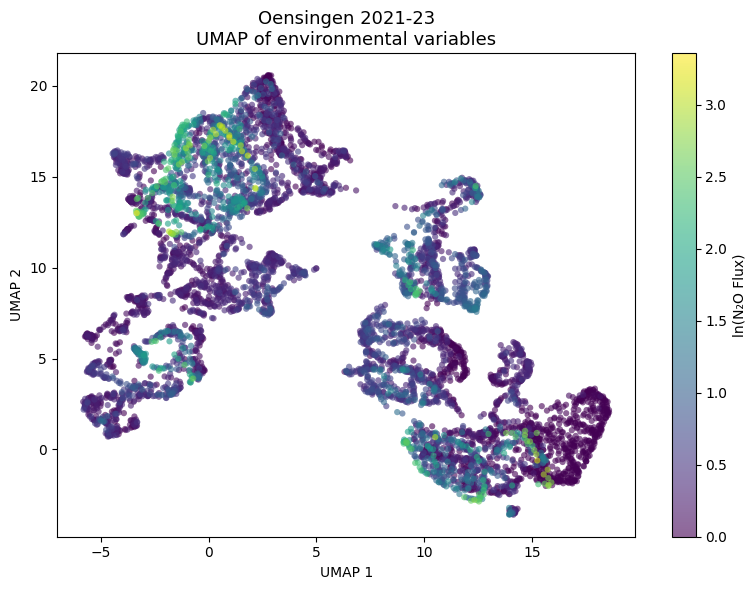

In [22]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
import umap
import matplotlib.cm as cm

# =============================================
# 1️⃣ Define variables and plotting function
# =============================================
base_vars = [
    "Precipitation", "SolarRadiation", "AirTemp", "VPD",
    "SoilWater_5cm", "SoilWater_15cm", "SoilWater_30cm",
    "SoilTemp_5cm", "SoilTemp_15cm", "SoilTemp_30cm",
    "NEE", "GPP", "RECO", "Mowing", "FertilizerMineral", "SoilCultivation"
]


def plot_umap(df, title, n_neighbors=50, min_dist=0.5, random_state=42):
    # Drop rows with missing values
    df_clean = df.dropna(subset=base_vars + ["N2O_Flux_ln"]).copy()

    # Standardize
    X_scaled = StandardScaler().fit_transform(df_clean[base_vars])

    # Run UMAP
    reducer = umap.UMAP(
        n_components=2,
        n_neighbors=n_neighbors,
        min_dist=min_dist,
        metric="euclidean",
        random_state=random_state
    )
    embedding = reducer.fit_transform(X_scaled)
    df_clean["UMAP1"] = embedding[:, 0]
    df_clean["UMAP2"] = embedding[:, 1]

    # Sort by N2O_Flux so high values are plotted last (on top)
    df_clean = df_clean.sort_values("N2O_Flux_ln", ascending=True)

    # Plot
    fig, ax = plt.subplots(figsize=(8, 6))
    sc = ax.scatter(
        df_clean["UMAP1"], df_clean["UMAP2"],
        c=df_clean["N2O_Flux_ln"],
        cmap=cm.viridis,
        s=20, alpha=0.6, edgecolor="none"
    )

    ax.set_title(f"{title}\nUMAP of environmental variables", fontsize=13)
    ax.set_xlabel("UMAP 1")
    ax.set_ylabel("UMAP 2")
    cbar = plt.colorbar(sc, ax=ax)
    cbar.set_label("ln(N₂O Flux)")
    plt.tight_layout()
    plt.show()

# =============================================
# 2️⃣ Run for Oensingen 2021-23
# =============================================
plot_umap(oensingen_2_clean, "Oensingen 2021-23")

# t-SNE plots

In [42]:
from sklearn.preprocessing import StandardScaler

# Drop or fill NaNs
X_2 = X_2.dropna()
y_2 = y_2.loc[X_2.index]

# Scale predictors
X_scaled_2 = StandardScaler().fit_transform(X_2)

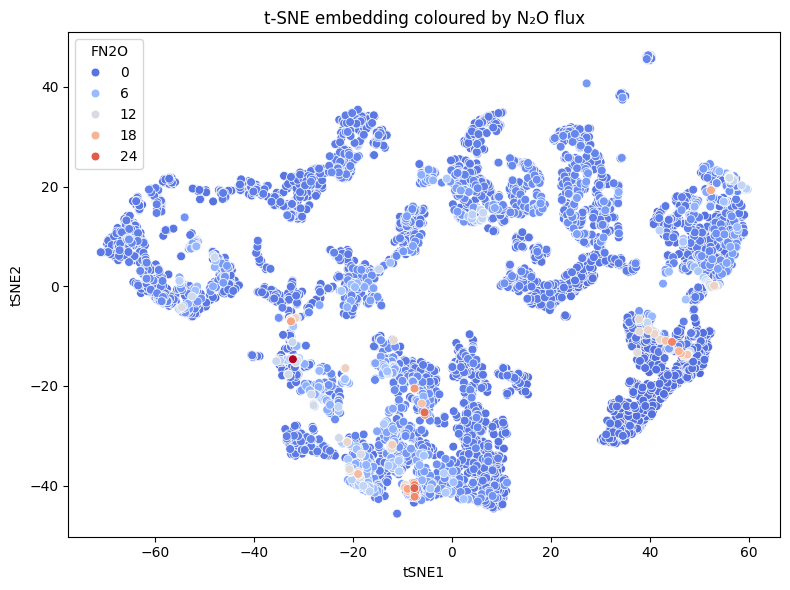

In [33]:
from sklearn.manifold import TSNE

tsne_2 = TSNE(n_components=2, perplexity=90, random_state=42)
X_tsne_2 = tsne_2.fit_transform(X_scaled_2)

tsne_df_2 = pd.DataFrame(X_tsne_2, columns=["tSNE1", "tSNE2"])
tsne_df_2["FN2O"] = y_2.values

plt.figure(figsize=(8,6))
sns.scatterplot(
    data=tsne_df_2, x="tSNE1", y="tSNE2",
    hue="FN2O", palette="coolwarm", s=40
)
plt.title("t-SNE embedding coloured by N₂O flux")
plt.tight_layout()
plt.show()

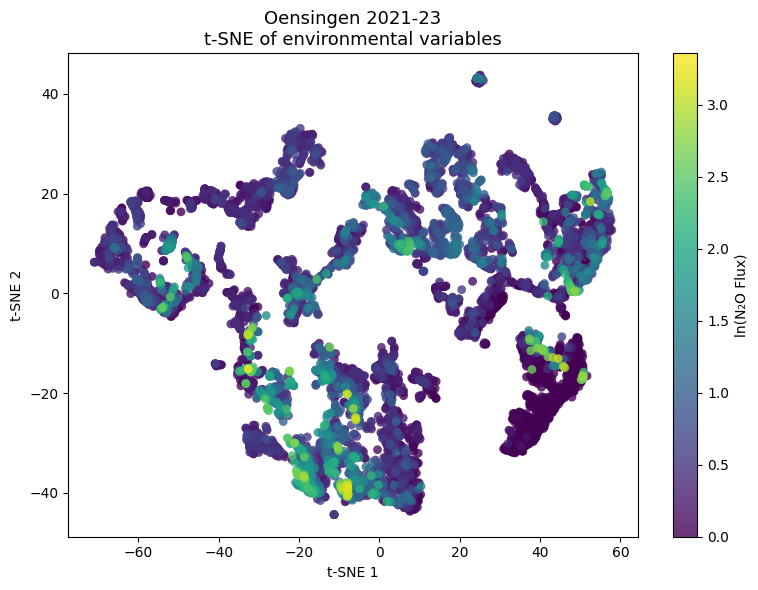

In [34]:
# =============================================
# 1️⃣ Define variables and plotting function
# =============================================
base_vars = [
    "Precipitation", "SolarRadiation", "AirTemp", "VPD",
    "SoilWater_5cm", "SoilWater_15cm", "SoilWater_30cm",
    "SoilTemp_5cm", "SoilTemp_15cm", "SoilTemp_30cm",
    "NEE", "GPP", "RECO", "Mowing", "FertilizerMineral", "SoilCultivation"
]

def plot_tsne(df, title, perplexity=100, learning_rate=200, random_state=42):
    # Drop missing values
    df_clean = df.dropna(subset=base_vars + ["N2O_Flux_ln"]).copy()

    # Standardize features
    X_scaled = StandardScaler().fit_transform(df_clean[base_vars])

    # Run t-SNE
    tsne = TSNE(
        n_components=2,
        perplexity=perplexity,
        learning_rate=learning_rate,
        init="pca",
        random_state=random_state
    )
    tsne_results = tsne.fit_transform(X_scaled)

    df_clean["tSNE1"] = tsne_results[:, 0]
    df_clean["tSNE2"] = tsne_results[:, 1]

    # Sort by N2O_Flux for plotting order
    df_clean = df_clean.sort_values("N2O_Flux_ln", ascending=True)

    # Plot
    fig, ax = plt.subplots(figsize=(8, 6))
    sc = ax.scatter(
        df_clean["tSNE1"], df_clean["tSNE2"],
        c=df_clean["N2O_Flux_ln"],
        cmap=cm.viridis,
        s=40, alpha=0.8, edgecolor="none"
    )

    ax.set_title(f"{title}\nt-SNE of environmental variables", fontsize=13)
    ax.set_xlabel("t-SNE 1")
    ax.set_ylabel("t-SNE 2")
    cbar = plt.colorbar(sc, ax=ax)
    cbar.set_label("ln(N₂O Flux)")
    plt.tight_layout()
    plt.show()

# =============================================
# 2️⃣ Run for Oensingen 2021-23
# =============================================
plot_tsne(oensingen_2_clean, "Oensingen 2021-23")